# LLMs as Creativity Assessors

In [1]:
%%html
<!-- hide-cell -->
<style>
.jp-Cell:has(#hide-marker) .jp-Cell-inputWrapper { display: none !important; }

.jp-MarkdownCell h1 {
  font-family: sans-serif;
  font-size: 35px;
  font-weight: 600;
  color: #111;
  margin: 2.5rem 0 0.75rem 0;
}
.jp-MarkdownCell h2 {
  font-family: sans-serif;
  font-size: 25px;
  font-weight: 600;
  color: #333;
  margin: 2rem 0 0.75rem 0;
}
</style>
<span id="hide-marker" style="display:none;"></span>
<style>
  .footnote { font-size:13px; color:#555; border-left:3px solid #ddd; padding:10px 14px; margin:1.5rem 0; border-radius:0 8px 8px 0; background:#f8f8f8; }
  .prose { font-size:15px; color:#111; line-height:1.75; margin:0 0 1rem 0; }
  .stat-grid { display:grid; grid-template-columns:repeat(auto-fit,minmax(140px,1fr)); gap:10px; margin:1.25rem 0; }
  .stat-card { background:#f8f8f8; border-radius:8px; padding:14px 16px; }
  .stat-label { font-size:12px; color:#777; margin:0 0 4px; }
  .stat-val { font-size:22px; font-weight:500; color:#111; margin:0; }
  .stat-sub { font-size:12px; color:#999; margin:4px 0 0; }
  .excl-row { display:flex; justify-content:space-between; font-size:13px; padding:7px 0; border-bottom:1px solid #eee; color:#333; }
  .excl-row:last-child { border-bottom:none; }
  .excl-n { font-weight:500; color:#777; }
  .kw-grid { display:grid; grid-template-columns:1fr 1fr; gap:10px; margin:1rem 0; }
  .kw-block { background:#f8f8f8; border-radius:8px; padding:12px 14px; }
  .kw-title { font-size:12px; font-weight:500; color:#777; margin:0 0 8px; text-transform:uppercase; letter-spacing:.05em; }
  .kw-list { margin:0; padding:0; list-style:none; }
  .kw-list li { font-size:13px; color:#333; padding:3px 0; border-bottom:1px solid #eee; }
  .kw-list li:last-child { border-bottom:none; }
  .design-card { background:#fff; border:1px solid #e5e5e5; border-radius:10px; padding:1rem 1.25rem; margin:1rem 0; }
  .design-label { font-size:12px; font-weight:500; color:#777; text-transform:uppercase; letter-spacing:.05em; margin:0 0 6px; }
  h3.section { font-size:15px; font-weight:500; color:#111; margin:1.75rem 0 0.5rem; border-bottom:1px solid #eee; padding-bottom:6px; }
    .nb-info { background:#dbeafe; border-left:3px solid #1d4ed8; border-radius:0 8px 8px 0; padding:14px 18px; display:flex; gap:12px; align-items:flex-start; margin-bottom:2rem; }
  .nb-info p { margin:0; font-size:14px; color:#1e3a8a; line-height:1.6; font-family:sans-serif; }
  .nb-info a { color:#1d4ed8; font-weight:500; }
  .rq { background:#f8f8f8; border-left:3px solid #aaa; padding:12px 18px; margin:1.25rem 0; }
  .rq p { margin:0; font-size:15px; color:#444; line-height:1.7; font-style:italic; }
  .section-label { font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#999; margin:0 0 8px 0; }
  .cat-card { background:#fff; border:1px solid #e5e5e5; border-radius:10px; padding:1rem 1.25rem; }
  .cat-header { display:flex; align-items:center; gap:8px; margin-bottom:12px; }
  .cat-badge { font-size:11px; font-weight:500; padding:3px 10px; border-radius:20px; margin-left:auto; }
  .cat-items { list-style:none; margin:0; padding:0; }
  .cat-items li { font-size:13px; color:#555; padding:5px 0; border-bottom:1px solid #f0f0f0; display:flex; gap:10px; line-height:1.4; }
  .cat-items li:last-child { border-bottom:none; }
  .ttcw-num { font-size:11px; font-weight:600; color:#aaa; min-width:52px; padding-top:1px; }
  .grid-2 { display:grid; grid-template-columns:repeat(auto-fit, minmax(280px, 1fr)); gap:12px; }
  .prose { font-size:15px; color:#444; line-height:1.75; margin:0 0 1rem 0; }
</style>

<div style="overflow: visible; height: auto; max-height: none;">


<link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/@tabler/icons-webfont@latest/tabler-icons.min.css">
<hr style="border:none; border-top:1px solid #eee; margin:1.5rem 0;">

<p class="prose">
Unlike human assessors, LLMs as judges can be applied across all stories without the risk of fatigue or dropout. This makes them useful for large-scale comparative judgment tasks where human annotation is expensive and difficult to replicate at scale.
</p>

<div class="nb-info">
  <i class="ti ti-info-circle" style="font-size:18px; color:#1d4ed8; margin-top:2px;"></i>
  <p>
    LLM-based judges are not used as a replacement for human evaluation, but as a 
    <b>controlled, reproducible measurement instrument</b>. Because the same model family is used across all items, any systematic bias is constant across conditions.
  </p>
</div>

<p class="prose">
The models that are used here are from the same family/developper as the LLMs used for story generation. It is a deliberate choice to use more cost-efficient variants for full coverage of the dataset (6048 API calls).
Prior work (e.g., Chakrabarty et al., 2024) shows minimal systematic differences in TTCW-style evaluations between frontier and smaller models within the same provider family. The use of same-provider evaluators is therefore important for preserving comparability/  enabling analysis of potential self-favour bias effects.
</p>
<p style="font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#aaa; margin:0 0 8px;">Assessor models</p>

<table style="width:100%; border-collapse:separate; border-spacing:8px 0; margin:0 -8px 14px -8px;">
  <tr style="vertical-align:top;">
    <td style="background:#f0f0f0; border-radius:10px; padding:12px 14px;">
      <div style="width:10px; height:10px; border-radius:50%; background:#444; margin-bottom:8px;"></div>
      <p style="font-size:13px; font-weight:500; color:#222; margin:0 0 1px;">Claude Haiku 4.5</p>
      <p style="font-size:11px; color:#999; margin:0 0 6px;">Anthropic</p>
      <p style="font-size:11px; color:#bbb; margin:0;">Generator: Claude Opus 4.1</p>
    </td>
    <td style="background:#ebebeb; border-radius:10px; padding:12px 14px;">
      <div style="width:10px; height:10px; border-radius:50%; background:#777; margin-bottom:8px;"></div>
      <p style="font-size:13px; font-weight:500; color:#222; margin:0 0 1px;">GPT-4o mini</p>
      <p style="font-size:11px; color:#999; margin:0 0 6px;">OpenAI</p>
      <p style="font-size:11px; color:#bbb; margin:0;">Generator: GPT-4o</p>
    </td>
    <td style="background:#e4e4e4; border-radius:10px; padding:12px 14px;">
      <div style="width:10px; height:10px; border-radius:50%; background:#aaa; margin-bottom:8px;"></div>
      <p style="font-size:13px; font-weight:500; color:#222; margin:0 0 1px;">Gemini 2.5 Flash</p>
      <p style="font-size:11px; color:#999; margin:0 0 6px;">Google</p>
      <p style="font-size:11px; color:#bbb; margin:0;">Generator: Gemini 3 Pro</p>
    </td>
  </tr>
</table>

<p style="font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#aaa; margin:0 0 8px;">API pipeline — per story × item call</p>

<div style="background:#fffbeb; border-left:3px solid #f59e0b; border-radius:0 8px 8px 0; padding:12px 16px; font-size:13px; color:#78350f; line-height:1.6;">
  <i class="ti ti-info-circle" style="font-size:14px; vertical-align:-2px; margin-right:6px;"></i>
  Full prompts and API pipeline code can be found at <code><a href="https://github.com/liseferinga/HumanLLMStories">https://github.com/liseferinga/HumanLLMStories</a></code>.
</div>
<br>

<div style="background:#fafafa; border-radius:12px; padding:18px 20px; margin-bottom:16px; border:1px solid #eee;">

  <!-- INPUT HEADER -->
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:10px;">
    <div style="background:#e8eefb; border-radius:6px; padding:6px 10px; font-size:11px; font-weight:700; color:#3a5fa8;">
      INPUT
    </div>
    <div style="font-size:12px; color:#777;">
      Information provided to the model per story
    </div>
  </div>

  <!-- INPUT CARDS -->
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:10px; margin-bottom:14px;">

    <div style="background:#fff; border:1px solid #e6e6e6; border-radius:10px; padding:10px 12px;">
      <div style="font-size:12px; font-weight:600; color:#222; margin-bottom:4px;">
        <i class="ti ti-file-text" style="color:#3a5fa8; margin-right:6px;"></i>Story text
      </div>
      <div style="font-size:11px; color:#777;">
        Full narrative without source label
      </div>
    </div>

    <div style="background:#fff; border:1px solid #e6e6e6; border-radius:10px; padding:10px 12px;">
      <div style="font-size:12px; font-weight:600; color:#222; margin-bottom:4px;">
        <i class="ti ti-book" style="color:#3a5fa8; margin-right:6px;"></i>TTCW context
      </div>
      <div style="font-size:11px; color:#777;">
        Dimension definition for evaluation
      </div>
    </div>

    <div style="background:#fff; border:1px solid #e6e6e6; border-radius:10px; padding:10px 12px;">
      <div style="font-size:12px; font-weight:600; color:#222; margin-bottom:4px;">
        <i class="ti ti-help-circle" style="color:#3a5fa8; margin-right:6px;"></i>Binary question
      </div>
      <div style="font-size:11px; color:#777;">
        Identical prompt across all items
      </div>
    </div>

    <div style="background:#fff; border:1px solid #e6e6e6; border-radius:10px; padding:10px 12px;">
      <div style="font-size:12px; font-weight:600; color:#222; margin-bottom:4px;">
        <i class="ti ti-brain" style="color:#3a5fa8; margin-right:6px;"></i>Reasoning instruction
      </div>
      <div style="font-size:11px; color:#777;">
        Model explains first, then answers
      </div>
    </div>

  </div>

  <!-- FLOW ARROW -->
  <div style="display:flex; justify-content:center; margin:6px 0 10px;">
    <div style="text-align:center; color:#bbb;">
      <div style="width:2px; height:14px; background:#ddd; margin:0 auto;"></div>
      <i class="ti ti-arrow-down" style="font-size:16px;"></i>
    </div>
  </div>

  <!-- MODEL -->
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:10px;">
    <div style="background:#f0f4ff; border-radius:6px; padding:6px 10px; font-size:11px; font-weight:700; color:#3a5fa8;">
      MODEL
    </div>
    <div style="font-size:12px; color:#444;">
      Processes narrative evidence and produces structured judgment
    </div>
  </div>

  <div style="background:#fff; border:1px solid #e6e6e6; border-radius:10px; padding:12px 14px; margin-bottom:10px;">
    <div style="font-size:12px; color:#333; line-height:1.6;">
      Reasoning over story content → outputs free-text explanation → final binary decision (<code>ja</code>/<code>nee</code>)
    </div>
  </div>

  <!-- FLOW ARROW -->
  <div style="display:flex; justify-content:center; margin:6px 0 10px;">
    <div style="text-align:center; color:#bbb;">
      <div style="width:2px; height:14px; background:#ddd; margin:0 auto;"></div>
      <i class="ti ti-arrow-down" style="font-size:16px;"></i>
    </div>
  </div>

  <!-- OUTPUT -->
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:10px;">
    <div style="background:#e6f4ec; border-radius:6px; padding:6px 10px; font-size:11px; font-weight:700; color:#2a6640;">
      OUTPUT
    </div>
    <div style="font-size:12px; color:#777;">
      Extracted decision and stored result
    </div>
  </div>

  <div style="display:grid; grid-template-columns:1fr 1fr; gap:10px;">

    <div style="background:#fff; border:1px solid #e6e6e6; border-radius:10px; padding:10px 12px;">
      <div style="font-size:12px; font-weight:600; color:#222; margin-bottom:4px;">
        <i class="ti ti-check" style="color:#2a6640; margin-right:6px;"></i>Parsed answer
      </div>
      <div style="font-size:11px; color:#777;">
        Final <code>ja</code>/<code>nee</code> extracted from output
      </div>
    </div>

    <div style="background:#fff; border:1px solid #e6e6e6; border-radius:10px; padding:10px 12px;">
      <div style="font-size:12px; font-weight:600; color:#222; margin-bottom:4px;">
        <i class="ti ti-device-floppy" style="color:#2a6640; margin-right:6px;"></i>Storage
      </div>
      <div style="font-size:11px; color:#777;">
        Appended to <code>llm_assessor_results.csv</code>
      </div>
    </div>

  </div>

</div>


<p style="font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#aaa; margin:0 0 8px;">Data quality</p>
<p class="prose">
The dataset was refined through several filtering steps: a small number of model outputs were unparseable (no clear <code>ja</code>/<code>nee</code> decision), Gemini runs for one set were excluded due to a model issue, and the remaining data form the final analysis sample.
</p>
<table style="width:100%; border-collapse:separate; border-spacing:0 6px; margin-bottom:14px;">
  <tr>
    <td style="background:#f8f8f8; border-radius:8px 0 0 8px; padding:10px 14px; width:65%;">
      <div style="font-size:13px; font-weight:500; color:#222;">Raw API calls completed</div>
      <div style="font-size:12px; color:#aaa;">Across three sessions — API credit exhaustion + deprecated Gemini model mid-run</div>
    </td>
    <td style="background:#f8f8f8; border-radius:0 8px 8px 0; padding:10px 16px; text-align:right; white-space:nowrap;">
      <span style="font-size:22px; font-weight:500; color:#3a5fa8;">6,048</span>
      <span style="font-size:12px; color:#aaa; margin-left:3px;">rows</span>
    </td>
  </tr>
  <tr>
    <td style="background:#f8f8f8; border-radius:8px 0 0 8px; padding:10px 14px;">
      <div style="font-size:13px; font-weight:500; color:#222;">Unparseable responses excluded</div>
      <div style="font-size:12px; color:#aaa;">No unambiguous ja/nee found in model output</div>
    </td>
    <td style="background:#f8f8f8; border-radius:0 8px 8px 0; padding:10px 16px; text-align:right; white-space:nowrap;">
      <span style="font-size:22px; font-weight:500; color:#3a5fa8;">50</span>
      <span style="font-size:12px; color:#aaa; margin-left:3px;">0.8%</span>
    </td>
  </tr>
  <tr>
    <td style="background:#f8f8f8; border-radius:8px 0 0 8px; padding:10px 14px;">
      <div style="font-size:13px; font-weight:500; color:#222;">Gemini content blocks excluded</div>
      <div style="font-size:12px; color:#aaa;">Set 32, human story — model refused to process</div>
    </td>
    <td style="background:#f8f8f8; border-radius:0 8px 8px 0; padding:10px 16px; text-align:right; white-space:nowrap;">
      <span style="font-size:22px; font-weight:500; color:#3a5fa8;">3</span>
      <span style="font-size:12px; color:#aaa; margin-left:3px;">rows</span>
    </td>
  </tr>
  <tr>
    <td style="background:#e8eefb; border-radius:8px 0 0 8px; padding:10px 14px;">
      <div style="font-size:13px; font-weight:500; color:#3a5fa8;">Effective analysis dataset</div>
      <div style="font-size:12px; color:#7090c8;">Valid LLM assessor ratings used in all analyses</div>
    </td>
    <td style="background:#e8eefb; border-radius:0 8px 8px 0; padding:10px 16px; text-align:right; white-space:nowrap;">
      <span style="font-size:22px; font-weight:500; color:#3a5fa8;">5,995</span>
      <span style="font-size:12px; color:#7090c8; margin-left:3px;">rows</span>
    </td>
  </tr>
</table>


In [2]:
%%html
<!-- hide-cell -->
<style>
.jp-Cell:has(#hide-marker) .jp-Cell-inputWrapper { display: none !important; }
 
.jp-MarkdownCell h1 {
  font-family: sans-serif;
  font-size: 35px;
  font-weight: 600;
  color: #111;
  margin: 2.5rem 0 0.75rem 0;
}
.jp-MarkdownCell h2 {
  font-family: sans-serif;
  font-size: 25px;
  font-weight: 600;
  color: #333;
  margin: 2rem 0 0.75rem 0;
}
</style>
<span id="hide-marker" style="display:none;"></span>
 
<hr style="border:none;">
<div style="display:flex; align-items:stretch; gap:10px; margin-bottom:6px;">
    <div style="background:#eef2ff; border-radius:8px; padding:8px 14px; display:flex; align-items:center; justify-content:center;">
        <i class="ti ti-database" style="font-size:24px; color:#4338ca;"></i>
    </div>
    <div>
      <div style="display:flex; align-items:center; gap:8px;">
        <h1 style="font-size:27px; font-weight:600; color:black; margin:0; padding-left:15px;">Creating the clean dataset: LLM assessors</h1>
      </div>
      <p style="font-size:15px; color:#aaa; margin:2px 0 0 0; padding-left: 15px;">The pipeline loads <code>llm_assessor_results.csv</code>, applies quality checks and exclusion criteria, and exports one analysis-ready dataset.</p>
    </div>
</div>
<br>
<div style="background:#fff; border:1px solid #e5e5e5; border-radius:10px; padding:1rem 1.25rem; margin-bottom:1rem;">
  <p style="font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#888; margin:0 0 10px;">Pipeline steps</p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:6px;">
    <div style="display:flex; align-items:flex-start; gap:10px; background:#f8f8f8; border-radius:8px; padding:9px 12px;">
      <span style="font-size:11px; font-weight:700; color:#000000; min-width:20px; padding-top:1px;">1</span>
      <span style="font-size:13px; color:#333;">Load raw export &amp; clean column names</span>
    </div>
    <div style="display:flex; align-items:flex-start; gap:10px; background:#f8f8f8; border-radius:8px; padding:9px 12px;">
      <span style="font-size:11px; font-weight:700; color:#000000; min-width:20px; padding-top:1px;">2</span>
      <span style="font-size:13px; color:#333;">Rename columns for clarity (align with human-rater naming)</span>
    </div>
    <div style="display:flex; align-items:flex-start; gap:10px; background:#f8f8f8; border-radius:8px; padding:9px 12px;">
      <span style="font-size:11px; font-weight:700; color:#000000; min-width:20px; padding-top:1px;">3</span>
      <span style="font-size:13px; color:#333;">Compute TTCW subscale scores per story × assessor</span>
    </div>
    <div style="display:flex; align-items:flex-start; gap:10px; background:#f8f8f8; border-radius:8px; padding:9px 12px;">
      <span style="font-size:11px; font-weight:700; color:#000000; min-width:20px; padding-top:1px;">4</span>
      <span style="font-size:13px; color:#333;">Apply exclusion criteria → clean dataset</span>
    </div>
    <div style="display:flex; align-items:flex-start; gap:10px; background:#f8f8f8; border-radius:8px; padding:9px 12px;">
      <span style="font-size:11px; font-weight:700; color:#000000; min-width:20px; padding-top:1px;">5</span>
      <span style="font-size:13px; color:#333;">Print exclusion log &amp; export final dataset</span>
    </div>
  </div>
</div>

In [3]:
%%html
<!-- hide-cell -->
<style>
.jp-Cell:has(#hide-marker) .jp-Cell-inputWrapper { display: none !important; }
 
.jp-MarkdownCell h1 {
  font-family: sans-serif;
  font-size: 35px;
  font-weight: 600;
  color: #111;
  margin: 2.5rem 0 0.75rem 0;
}
.jp-MarkdownCell h2 {
  font-family: sans-serif;
  font-size: 25px;
  font-weight: 600;
  color: #333;
  margin: 2rem 0 0.75rem 0;
}
</style>
<span id="hide-marker" style="display:none;"></span>
<div style="display:flex; align-items:flex-start; gap:10px; background:#f8f8f8; border-radius:8px; padding:9px 12px;">
    <span style="font-size:11px; font-weight:700; color:#000000; min-width:20px; padding-top:1px;">1</span>
    <span style="font-size:13px; color:#333;">Load raw export &amp; clean column names</span>
</div>

In [4]:
import pandas as pd
import numpy as np
 
df = pd.read_csv("llm_assessor_results.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
 
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (6048, 7)
Columns: ['set_num', 'source', 'item_id', 'dimension', 'assessor_llm', 'answer', 'answer_bin']


In [5]:
%%html
<!-- hide-cell -->
<style>
.jp-Cell:has(#hide-marker) .jp-Cell-inputWrapper { display: none !important; }
 
.jp-MarkdownCell h1 {
  font-family: sans-serif;
  font-size: 35px;
  font-weight: 600;
  color: #111;
  margin: 2.5rem 0 0.75rem 0;
}
.jp-MarkdownCell h2 {
  font-family: sans-serif;
  font-size: 25px;
  font-weight: 600;
  color: #333;
  margin: 2rem 0 0.75rem 0;
}
</style>
<span id="hide-marker" style="display:none;"></span>
<div style="display:flex; align-items:flex-start; gap:10px; background:#f8f8f8; border-radius:8px; padding:9px 12px;">
    <span style="font-size:11px; font-weight:700; color:#000000; min-width:20px; padding-top:1px;">2</span>
    <span style="font-size:13px; color:#333;">Rename columns to align with human-rater naming</span>
</div>

In [6]:
df = df.rename(columns={
    "set_num": "set",
    "item_id": "item",
    "assessor_llm": "assessor",
    "answer_bin": "pass",
})
 
df["author"] = df["source"].replace({
    "claude": "Claude", "gemini": "Gemini", "gpt": "GPT", "human": "Human",
})
df["source_binary"] = np.where(df["source"] == "human", "Human", "LLM")
df = df.drop(columns=["source"])
 
print(df[["set", "item", "dimension", "assessor", "author", "source_binary", "answer", "pass"]].head())

   set      item dimension assessor author source_binary answer  pass
0    1  Fluency1   Fluency   gemini  Human         Human     Ja   1.0
1    1  Fluency2   Fluency   gemini  Human         Human    Nee   0.0
2    1  Fluency3   Fluency   gemini  Human         Human    Nee   0.0
3    1  Fluency4   Fluency   gemini  Human         Human    Nee   0.0
4    1  Fluency5   Fluency   gemini  Human         Human    Nee   0.0


In [7]:
%%html
<!-- hide-cell -->
<style>
.jp-Cell:has(#hide-marker) .jp-Cell-inputWrapper { display: none !important; }
 
.jp-MarkdownCell h1 {
  font-family: sans-serif;
  font-size: 35px;
  font-weight: 600;
  color: #111;
  margin: 2.5rem 0 0.75rem 0;
}
.jp-MarkdownCell h2 {
  font-family: sans-serif;
  font-size: 25px;
  font-weight: 600;
  color: #333;
  margin: 2rem 0 0.75rem 0;
}
</style>
<span id="hide-marker" style="display:none;"></span>

<div style="display:flex; align-items:flex-start; gap:10px; background:#f8f8f8; border-radius:8px; padding:9px 12px;">
    <span style="font-size:11px; font-weight:700; color:#000000; min-width:20px; padding-top:1px;">3</span>
   <span style="font-size:13px; color:#333;">Compute TTCW subscale scores per story &times; assessor</span>
</div>

In [8]:
df_valid = df.dropna(subset=["pass"]).copy()
 
subscale_scores = (
    df_valid.groupby(["set", "author", "source_binary", "assessor", "dimension"])["pass"]
    .sum().reset_index().rename(columns={"pass": "subscale_score"})
)
total_scores = (
    df_valid.groupby(["set", "author", "source_binary", "assessor"])["pass"]
    .sum().reset_index().rename(columns={"pass": "total_score"})
)
 
print("Subscale scores (first rows):")
print(subscale_scores.head())
print("\nTotal scores (first rows):")
print(total_scores.head())

Subscale scores (first rows):
   set  author source_binary assessor    dimension  subscale_score
0    1  Claude           LLM   claude  Elaboration             2.0
1    1  Claude           LLM   claude  Flexibility             1.0
2    1  Claude           LLM   claude      Fluency             4.0
3    1  Claude           LLM   claude  Originality             1.0
4    1  Claude           LLM   gemini  Elaboration             2.0

Total scores (first rows):
   set  author source_binary assessor  total_score
0    1  Claude           LLM   claude          8.0
1    1  Claude           LLM   gemini         11.0
2    1  Claude           LLM      gpt         13.0
3    1     GPT           LLM   claude          6.0
4    1     GPT           LLM   gemini          7.0


In [9]:
%%html
<!-- hide-cell -->
<style>
.jp-Cell:has(#hide-marker) .jp-Cell-inputWrapper { display: none !important; }
 
.jp-MarkdownCell h1 {
  font-family: sans-serif;
  font-size: 35px;
  font-weight: 600;
  color: #111;
  margin: 2.5rem 0 0.75rem 0;
}
.jp-MarkdownCell h2 {
  font-family: sans-serif;
  font-size: 25px;
  font-weight: 600;
  color: #333;
  margin: 2rem 0 0.75rem 0;
}
</style>
<span id="hide-marker" style="display:none;"></span>
<div style="display:flex; align-items:flex-start; gap:10px; background:#f8f8f8; border-radius:8px; padding:9px 12px;">
  <span style="font-size:11px; font-weight:700; color:#000000; min-width:20px; padding-top:1px;">4</span>
  <span style="font-size:13px; color:#333;">Apply exclusion criteria and create a clean dataset</span>
</div>

In [10]:
is_error = df["answer"] == "ERROR"
is_nan = df["answer"].isna()
is_fluency_item = df["item"].isin(["Fluency1", "Fluency3"])
 
df["exclusion_reason"] = "Keep"
df.loc[is_error, "exclusion_reason"] = "API error"
df.loc[is_nan & is_fluency_item, "exclusion_reason"] = "Parsing gap (Fluency1/Fluency3)"
df.loc[is_nan & ~is_fluency_item, "exclusion_reason"] = "Parsing gap (other item)"
 
df_clean = df[df["exclusion_reason"] == "Keep"].copy()
print(f"Clean dataset: {df_clean.shape[0]} rows (from {df.shape[0]} raw rows)")

Clean dataset: 5998 rows (from 6048 raw rows)


In [11]:
%%html
<!-- hide-cell -->
<style>
.jp-Cell:has(#hide-marker) .jp-Cell-inputWrapper { display: none !important; }
 
.jp-MarkdownCell h1 {
  font-family: sans-serif;
  font-size: 35px;
  font-weight: 600;
  color: #111;
  margin: 2.5rem 0 0.75rem 0;
}
.jp-MarkdownCell h2 {
  font-family: sans-serif;
  font-size: 25px;
  font-weight: 600;
  color: #333;
  margin: 2rem 0 0.75rem 0;
}
</style>
<span id="hide-marker" style="display:none;"></span>
<div style="display:flex; align-items:flex-start; gap:10px; background:#f8f8f8; border-radius:8px; padding:9px 12px;">
   <span style="font-size:11px; font-weight:700; color:#000000; min-width:20px; padding-top:1px;">5</span>
   <span style="font-size:13px; color:#333;">Print exclusion log &amp; export final dataset<code>llm_assessor_clean.csv</code></span>
</div>

In [12]:
exclusion_log = df.groupby(["assessor", "exclusion_reason"]).size().unstack(fill_value=0)
 
all_reasons = ["API error", "Parsing gap (Fluency1/Fluency3)", "Parsing gap (other item)", "Keep"]
for col in all_reasons:
    if col not in exclusion_log.columns:
        exclusion_log[col] = 0
exclusion_log = exclusion_log[all_reasons]
 
exclusion_log["Total dropped"] = exclusion_log.drop(columns=["Keep"]).sum(axis=1)
exclusion_log = exclusion_log.rename(columns={"Keep": "Rows remaining"})
exclusion_log.loc["TOTAL"] = exclusion_log.sum()
 
print("=== Exclusion log ===")
print(exclusion_log)
print(f"\nFinal shape: {df_clean.shape} (dropped {len(df) - len(df_clean)} of {len(df)} rows, "
      f"{100 * (len(df) - len(df_clean)) / len(df):.2f}%)")
 
df_clean = df_clean.drop(columns=["exclusion_reason"])
df_clean.to_csv("llm_assessor_clean.csv", index=False)
print("\nExported to llm_assessor_clean.csv")

=== Exclusion log ===
exclusion_reason  API error  Parsing gap (Fluency1/Fluency3)  \
assessor                                                       
claude                    0                               40   
gemini                    3                                5   
gpt                       0                                0   
TOTAL                     3                               45   

exclusion_reason  Parsing gap (other item)  Rows remaining  Total dropped  
assessor                                                                   
claude                                   0            1976             40  
gemini                                   2            2006             10  
gpt                                      0            2016              0  
TOTAL                                    2            5998             50  

Final shape: (5998, 9) (dropped 50 of 6048 rows, 0.83%)

Exported to llm_assessor_clean.csv


In [13]:
%%html
<!-- hide-cell -->
<style>
.jp-Cell:has(#hide-marker) .jp-Cell-inputWrapper { display: none !important; }
.jp-MarkdownCell h1 {
  font-family: sans-serif;
  font-size: 35px;
  font-weight: 600;
  color: #111;
  margin: 2.5rem 0 0.75rem 0;
}
.jp-MarkdownCell h2 {
  font-family: sans-serif;
  font-size: 25px;
  font-weight: 600;
  color: #333;
  margin: 2rem 0 0.75rem 0;
}
</style>
<span id="hide-marker" style="display:none;"></span>
<hr style="border:none; border-top:1px solid #eee; margin:1.5rem 0;">
<div style="display:flex; align-items:stretch; gap:10px; margin-bottom:6px;">
    <div style="background:#eef2ff; border-radius:8px; padding:8px 14px; display:flex; align-items:center; justify-content:center;">
      <i class="ti ti-chart-bar" style="font-size:24px; color:#4338ca;"></i>
    </div>
    <div>
      <div style="display:flex; align-items:center; gap:8px;">
        <h1 style="font-size:27px; font-weight:600; color:black; margin:0; padding-left:15px;">Descriptive statistics — LLM assessors</h1>
      </div>
      <p style="font-size:15px; color:#aaa; margin:2px 0 0 0; padding-left:15px;">Mean TTCW scores, pass rates, self - vs. cross-assessment comparison, and attribution accuracy, computed from the clean dataset.</p>
    </div>
</div>
<div style="display:flex; flex-direction:column; gap:6px;">
  <div style="display:flex; align-items:flex-start; gap:12px; padding:10px 12px; background:#f8f8f8; border-radius:8px;">
    <span style="font-size:11px; font-weight:700; color:#4338ca; min-width:20px; padding-top:1px;">1</span>
    <div>
      <p style="margin:0 0 2px; font-size:13px; font-weight:500; color:#222;">Mean TTCW total &amp; dimension scores per author</p>
      <p style="margin:0; font-size:12px; color:#777;">Broken down by assessor (Claude/GPT/Gemini) → saved to <code>desc_llm_scores.csv</code></p>
    </div>
  </div>
  <div style="display:flex; align-items:flex-start; gap:12px; padding:10px 12px; background:#f8f8f8; border-radius:8px; margin-left:5px;">
    <span style="font-size:11px; font-weight:700; color:#4338ca; min-width:20px; padding-top:1px;">2</span>
    <div>
      <p style="margin:0 0 2px; font-size:13px; font-weight:500; color:#222;">Pass rates per item per author</p>
      <p style="margin:0; font-size:12px; color:#777;">For one specific item (e.g. "Fluency3"), what % of all assessor ratings on that item were "ja"?</p>
    </div>
  </div>
  <div style="display:flex; align-items:flex-start; gap:12px; padding:10px 12px; background:#f8f8f8; border-radius:8px; margin-left:5px;">
    <span style="font-size:11px; font-weight:700; color:#4338ca; min-width:20px; padding-top:1px;">3</span>
    <div>
      <p style="margin:0 0 2px; font-size:13px; font-weight:500; color:#222;">Self- vs. cross-assessment pass rates</p>
      <p style="margin:0; font-size:12px; color:#777;">Does an assessor rate stories it wrote itself differently than stories from other sources (other LLMs or human)? → saved to <code>desc_llm_selfassessment.csv</code></p>
    </div>
  </div>
  <div style="display:flex; align-items:flex-start; gap:12px; padding:10px 12px; background:#f8f8f8; border-radius:8px; margin-left:5px;">
    <span style="font-size:11px; font-weight:700; color:#4338ca; min-width:20px; padding-top:1px;">4</span>
    <div>
      <p style="margin:0 0 2px; font-size:13px; font-weight:500; color:#222;">Attribution accuracy by order &amp; assessor</p>
      <p style="margin:0; font-size:12px; color:#777;">% of assessors who correctly identified the AI-written story → saved to <code>desc_llm_attribution.csv</code></p>
    </div>
  </div>
</div>

In [39]:
import pandas as pd
import numpy as np
from IPython.display import display as ipy_display

# ── Load ICC result ───────────────────────────────────────────────────────────
icc_summary = pd.read_csv("icc_summary.csv")
icc_val = round(icc_summary["icc"].iloc[0], 3)

def icc_label(val):
    if val < 0.50:
        return f"{val:.2f} (Poor)"
    elif val < 0.75:
        return f"{val:.2f} (Moderate)"
    elif val < 0.90:
        return f"{val:.2f} (Good)"
    else:
        return f"{val:.2f} (Excellent)"

# ── Compute total scores per rater × source ───────────────────────────────────
# df_clean has item-level ratings — sum to get total score per (set, author, assessor)
total_scores = (
    df_clean.groupby(["set", "author", "assessor"])["pass"]
    .sum()
    .reset_index()
    .rename(columns={"pass": "total_score"})
)

# ── Summary stats per source ──────────────────────────────────────────────────
def summarise(df_sub, model_label, source_label, icc_str):
    return {
        "Model":   model_label,
        "Source":  source_label,
        "N":       len(df_sub),
        "Mean":    round(df_sub["total_score"].mean(), 2),
        "Median":  round(df_sub["total_score"].median(), 2),
        "SD":      round(df_sub["total_score"].std(), 2),
        "Min":     int(df_sub["total_score"].min()),
        "Max":     int(df_sub["total_score"].max()),
        "ICC (2,1)": icc_str,
    }

rows = []

# ── All LLM raters pooled ─────────────────────────────────────────────────────
rows.append(summarise(
    total_scores[total_scores["author"] == "Human"],
    "All LLM-raters (pooled)", "Human stories", icc_label(icc_val)
))
rows.append(summarise(
    total_scores[total_scores["author"] != "Human"],
    "", "LLM stories", ""
))

# ── Per judge ─────────────────────────────────────────────────────────────────
for judge in ["claude", "gemini", "gpt"]:
    judge_df = total_scores[total_scores["assessor"] == judge]
    rows.append(summarise(
        judge_df[judge_df["author"] == "Human"],
        judge.capitalize(), "Human stories", ""
    ))
    rows.append(summarise(
        judge_df[judge_df["author"] != "Human"],
        "", "LLM stories", ""
    ))

table = pd.DataFrame(rows)

# ── Style ─────────────────────────────────────────────────────────────────────
def style_rows(row):
    is_header = row["Model"] != ""
    return ["font-weight: bold" if is_header else "" for _ in row.index]

ipy_display(
    table.style
    .apply(style_rows, axis=1)
    .hide(axis="index")
    .format({
        "Mean":   "{:.2f}",
        "Median": "{:.2f}",
        "SD":     "{:.2f}",
    })
    .set_caption(
        "Descriptive statistics for LLM-judge TTCW total scores (0–14) by model and story source. "
        "ICC (2,1) = intraclass correlation coefficient, two-way random effects, single rater, absolute agreement, "
        "computed on human stories only across the three LLM judges."
    )
    .set_table_styles([
        {"selector": "thead th", "props": [("text-align", "left")]},
        {"selector": "caption",  "props": [("text-align", "left")]},
        {"selector": "td",       "props": [("text-align", "left")]},
    ])
)

Model,Source,N,Mean,Median,SD,Min,Max,"ICC (2,1)"
All LLM-raters (pooled),Human stories,108,9.64,10.00,2.15,3,13,0.47 (Poor)
,LLM stories,324,9.40,10.00,2.71,0,13,
Claude,Human stories,36,7.50,7.00,1.75,3,11,
,LLM stories,108,6.86,7.00,2.65,0,11,
Gemini,Human stories,36,10.17,10.00,1.42,5,12,
,LLM stories,108,10.08,10.00,1.72,2,13,
Gpt,Human stories,36,11.25,11.00,1.16,8,13,
,LLM stories,108,11.27,11.00,1.32,3,13,


In [14]:
import pandas as pd
import numpy as np

df_clean = pd.read_csv("llm_assessor_clean.csv")  # from the cleaning pipeline

# --- Subscale scores: aggregate to ONE SCORE PER CALL first (set x author x
# assessor x dimension), THEN take mean/median/SD/min/max across calls.
# Doing this directly on the raw 0/1 `pass` column would be degenerate --
# min/max would always be exactly 0%/100%, since a single item rating is binary.
subscale_per_call = (
    df_clean.groupby(["set", "author", "assessor", "dimension"])["pass"]
    .sum().reset_index().rename(columns={"pass": "subscale_score"})
)
subscale_means = (
    subscale_per_call.groupby(["author", "dimension"])["subscale_score"]
    .agg(mean="mean", median="median", sd="std", min="min", max="max", n="count")
    .round(2).reset_index()
)

# --- Total scores: already aggregated to one score PER CALL (0-14), so
# mean/min/max here are genuinely informative -- just adding median/min/max
# alongside the mean+sd you already had.
total_per_call = (
    df_clean.groupby(["set", "author", "assessor"])["pass"]
    .sum().reset_index().rename(columns={"pass": "total_score"})
)
total_means = (
    total_per_call.groupby("author")["total_score"]
    .agg(mean="mean", median="median", sd="std", min="min", max="max", n="count")
    .round(2).reset_index()
)

print("Subscale score (0-5 Fluency, 0-3 others) by author x dimension:")
print(subscale_means)
print("\nTotal score (0-14) by author:")
print(total_means)

subscale_means.to_csv("desc_llm_scores.csv", index=False)
total_means.to_csv("desc_llm_total_scores.csv", index=False)

# If "always exactly one flaw" is a real behavioral pattern (not chance),
# the distribution of total_score should pile up suspiciously at 13 rather
# than spreading out the way independent item-level failures would predict.
print("Total score distribution, all calls:")
print(total_per_call["total_score"].value_counts().sort_index())

print("\nTotal score distribution, by author:")
print(total_per_call.groupby(["author", "total_score"]).size().unstack(fill_value=0))

# Sanity check: under independence, what's the expected probability of a
# perfect 14/14 call, using each item's actual marginal pass rate?
item_pass_rates = df_clean.groupby("item")["pass"].mean()
prob_all_14 = item_pass_rates.prod()
expected_perfect_calls = prob_all_14 * len(total_per_call)
print(f"\nP(all 14 items pass | independence) = {prob_all_14:.5f}")
print(f"Expected number of perfect calls across {len(total_per_call)} calls: {expected_perfect_calls:.2f}")
print(f"Actual number of perfect calls observed: {(total_per_call['total_score'] == 14).sum()}")

# If there's a "reluctance to give 14" bias specifically, calls that get
# 13 should disproportionately have their single "Nee" scattered across
# MANY different items (not concentrated on the hard ones we already found)
near_perfect = total_per_call[total_per_call["total_score"] == 13]
near_perfect_keys = list(near_perfect[["set", "author", "assessor"]].itertuples(index=False, name=None))
df_clean["_call_key"] = list(zip(df_clean["set"], df_clean["author"], df_clean["assessor"]))
failed_item_in_near_perfect = df_clean[
    (df_clean["_call_key"].isin(near_perfect_keys)) & (df_clean["pass"] == 0)
]
print("\nWhich item was the single failure, among 13/14 calls:")
print(failed_item_in_near_perfect["item"].value_counts())

Subscale score (0-5 Fluency, 0-3 others) by author x dimension:
    author    dimension  mean  median    sd  min  max    n
0   Claude  Elaboration  2.19     2.0  0.50  1.0  3.0  108
1   Claude  Flexibility  1.87     2.0  0.71  0.0  3.0  108
2   Claude      Fluency  4.29     5.0  0.93  1.0  5.0  108
3   Claude  Originality  1.74     2.0  0.79  0.0  3.0  108
4      GPT  Elaboration  1.94     2.0  0.64  0.0  3.0  108
5      GPT  Flexibility  1.40     2.0  0.83  0.0  3.0  108
6      GPT      Fluency  3.72     4.0  1.41  0.0  5.0  108
7      GPT  Originality  1.01     1.0  0.89  0.0  3.0  108
8   Gemini  Elaboration  2.19     2.0  0.60  0.0  3.0  108
9   Gemini  Flexibility  2.02     2.0  0.68  0.0  3.0  108
10  Gemini      Fluency  4.01     4.0  1.15  0.0  5.0  108
11  Gemini  Originality  1.84     2.0  0.69  0.0  3.0  108
12   Human  Elaboration  2.01     2.0  0.46  1.0  3.0  108
13   Human  Flexibility  1.93     2.0  0.75  0.0  3.0  108
14   Human      Fluency  3.86     4.0  1.10  0.0  5

In [40]:
import pandas as pd

QUESTION_LABELS = {
    "Fluency1":      ("Narrative Pacing",                "Fluency"),
    "Fluency2":      ("Scene vs. Exposition",            "Fluency"),
    "Fluency3":      ("Literary Devices & Language",     "Fluency"),
    "Fluency4":      ("Narrative Ending",                "Fluency"),
    "Fluency5":      ("Understandability & Coherence",   "Fluency"),
    "Flexibility1":  ("Emotional Flexibility",           "Flexibility"),
    "Flexibility2":  ("Perspective & Voice Flexibility", "Flexibility"),
    "Flexibility3":  ("Structural Flexibility",          "Flexibility"),
    "Originality1":  ("Originality in Form",             "Originality"),
    "Originality2":  ("Originality in Thought",          "Originality"),
    "Originality3":  ("Originality in Theme & Content",  "Originality"),
    "Elaboration1":  ("World Building & Setting",        "Elaboration"),
    "Elaboration2":  ("Character Development",           "Elaboration"),
    "Elaboration3":  ("Rhetorical Complexity",           "Elaboration"),
}

def pass_rate_col(df_subset, item_col="item"):
    grouped = (
        df_subset.groupby(item_col)["pass"]
        .agg(n="count", passed="sum")
        .reset_index()
    )
    grouped["pass_rate"] = (grouped["passed"] / grouped["n"] * 100).round(1)
    grouped["N"] = grouped["n"]
    return grouped.set_index(item_col)[["pass_rate", "N"]]

def make_full_table(df_judge, judge_label):
    items = sorted(df_judge["item"].unique(),
                   key=lambda x: list(QUESTION_LABELS.keys()).index(x) if x in QUESTION_LABELS else 99)

    # ── Build columns ─────────────────────────────────────────────────────────
    col_data = {}

    # LLM total
    llm_df = df_judge[df_judge["source_binary"] == "LLM"]
    col_data["LLM (total)"] = pass_rate_col(llm_df)

    # LLM broken by author
    for llm_author in sorted(llm_df["author"].unique()):
        sub = llm_df[llm_df["author"] == llm_author]
        col_data[f"LLM: {llm_author.capitalize()}"] = pass_rate_col(sub)

    # Human
    human_df = df_judge[df_judge["source_binary"] == "Human"]
    col_data["Human"] = pass_rate_col(human_df)

    # ── Assemble pivot ────────────────────────────────────────────────────────
    result = pd.DataFrame(index=items)
    result["Question"]  = result.index.map(lambda i: QUESTION_LABELS.get(i, (i, ""))[0])
    result["Dimension"] = result.index.map(lambda i: QUESTION_LABELS.get(i, (i, ""))[1])

    for col_label, rates in col_data.items():
        n_total = int(rates["N"].sum())
        full_label = f"{col_label} (N={n_total})"
        result[full_label] = result.index.map(
            lambda i, r=rates: r.loc[i, "pass_rate"] if i in r.index else float("nan")
        )

    result = result.reset_index(drop=True)

    # ── Average row ───────────────────────────────────────────────────────────
    avg_row = {"Question": "Average", "Dimension": ""}
    for c in result.columns:
        if c not in ["Question", "Dimension"]:
            avg_row[c] = round(result[c].mean(), 1)
    result = pd.concat([result, pd.DataFrame([avg_row])], ignore_index=True)

    print(f"\n{'='*70}")
    print(f"{judge_label.upper()} AS JUDGE")
    print(f"{'='*70}")
    print(result.to_string(index=False))
    return result

# ── One table per judge ───────────────────────────────────────────────────────
tables = {}
for judge in sorted(df_clean["assessor"].unique()):
    tables[judge] = make_full_table(
        df_clean[df_clean["assessor"] == judge],
        judge
    )
# ── All judges combined ───────────────────────────────────────────────────────
tables["all"] = make_full_table(df_clean, "All judges combined")


CLAUDE AS JUDGE
                       Question   Dimension  LLM (total) (N=1480)  LLM: Claude (N=494)  LLM: Gpt (N=499)  LLM: Gemini (N=487)  Human (N=496)
               Narrative Pacing     Fluency                  62.2                 96.8               8.3                 90.3           88.2
           Scene vs. Exposition     Fluency                  14.8                 25.0               0.0                 19.4           11.1
    Literary Devices & Language     Fluency                  43.0                 61.3               3.2                 70.8           40.0
               Narrative Ending     Fluency                  89.8                 86.1              91.7                 91.7           75.0
  Understandability & Coherence     Fluency                  95.4                100.0              91.7                 94.4           91.7
          Emotional Flexibility Flexibility                   2.8                  0.0               0.0                  8.3            

In [41]:
import pandas as pd

df = pd.read_csv("llm_assessor_clean.csv")
df["assessor"] = df["assessor"].str.lower()

def cell_stats(sub, unit_cols):
    n = len(sub)
    n_passed = int(sub["pass"].sum())
    mean_pct = 100 * n_passed / n
    # Min/Max = range across the 14 TTCW items' own pass rates within this cell
    # (the substitute "rater" unit for LLMs -- see note below)
    item_rates = sub.groupby(unit_cols)["pass"].mean() * 100
    return n, n_passed, mean_pct, item_rates.min(), item_rates.max()

MODEL_LABELS = {"claude": "Claude", "gemini": "Gemini", "gpt": "GPT"}

rows = []
for source in ["Human", "LLM"]:
    sub = df[df["source_binary"] == source]
    n, npass, mean_pct, mn, mx = cell_stats(sub, ["assessor", "item"])
    rows.append(("All LLM-raters (pooled)", f"{source} stories", n, npass, mean_pct, mn, mx))

for assessor in ["claude", "gemini", "gpt"]:
    for source in ["Human", "LLM"]:
        sub = df[(df["assessor"] == assessor) & (df["source_binary"] == source)]
        n, npass, mean_pct, mn, mx = cell_stats(sub, "item")
        rows.append((MODEL_LABELS[assessor], f"{source} stories", n, npass, mean_pct, mn, mx))

table_llm = pd.DataFrame(
    rows, columns=["Model", "Source", "N", "N passed", "Mean pass rate (%)", "Min (%)", "Max (%)"]
)
print(table_llm.to_string(index=False))

                  Model        Source    N  N passed  Mean pass rate (%)   Min (%)    Max (%)
All LLM-raters (pooled) Human stories 1500      1041           69.400000  0.000000 100.000000
All LLM-raters (pooled)   LLM stories 4498      3047           67.741218  2.777778  99.074074
                 Claude Human stories  496       270           54.435484  0.000000 100.000000
                 Claude   LLM stories 1480       741           50.067568  2.777778  95.370370
                 Gemini Human stories  500       366           73.200000 11.111111 100.000000
                 Gemini   LLM stories 1506      1089           72.310757 16.666667  97.222222
                    GPT Human stories  504       405           80.357143 11.111111 100.000000
                    GPT   LLM stories 1512      1217           80.489418 10.185185  99.074074


In [42]:
attr = pd.read_csv("llm_attribution_results.csv")

attribution_table = (
    attr.groupby("assessor_llm")["correct"]
    .agg(N="count", n_correct="sum", **{"Accuracy (%)": "mean"})
    .reset_index()
)
attribution_table["Accuracy (%)"] = (attribution_table["Accuracy (%)"] * 100).round(1)
attribution_table["n_correct"] = attribution_table["n_correct"].astype(int)

attribution_table["Accuracy (%)"] = attribution_table.apply(
    lambda row: f"{row['Accuracy (%)']:.1f} (n={row['n_correct']}/{row['N']})", axis=1
)

attribution_table = attribution_table.rename(columns={"assessor_llm": "Assessor"})
attribution_table["Assessor"] = attribution_table["Assessor"].str.capitalize()
display = attribution_table[["Assessor", "N", "Accuracy (%)"]]

(
    display.style
    .hide(axis="index")
    .set_caption(
        "Table: Attribution accuracy by judge. N = number of attribution calls; "
        "Accuracy (%) = proportion of calls where the judge correctly identified the "
        "AI-written story."
    )
    .set_table_styles([
        {"selector": "thead th", "props": [("text-align", "left")]},
        {"selector": "caption", "props": [("text-align", "left")]},
        {"selector": "td", "props": [("text-align", "left")]},
    ])
)

Assessor,N,Accuracy (%)
Claude,108,52.8 (n=57/108)
Gemini,108,72.2 (n=78/108)
Gpt,108,51.9 (n=56/108)


In [18]:
from scipy.stats import binomtest
from statsmodels.stats.proportion import proportion_confint

data = [
    ("Claude", 57, 108),
    ("Gemini", 78, 108),
    ("GPT",    56, 108),
]

print(f"{'Judge':<10} {'Accuracy':>10} {'95% CI':>22} {'p (vs. chance)':>16}")
print("-" * 62)

for judge, k, n in data:
    result = binomtest(k, n, p=0.5, alternative="two-sided")
    lo, hi = proportion_confint(k, n, alpha=0.05, method="wilson")
    acc = k / n * 100
    p = result.pvalue
    p_str = "< .001" if p < 0.001 else f"= .{int(round(p, 3) * 1000):03d}"
    print(f"{judge:<10} {acc:>9.1f}%  [{lo*100:4.1f}%, {hi*100:4.1f}%]   p {p_str}")


Judge        Accuracy                 95% CI   p (vs. chance)
--------------------------------------------------------------
Claude          52.8%  [43.4%, 61.9%]   p = .631
Gemini          72.2%  [63.1%, 79.8%]   p < .001
GPT             51.9%  [42.5%, 61.0%]   p = .773


In [19]:
%%html
<!-- hide-cell -->
<style>
.jp-Cell:has(#hide-marker) .jp-Cell-inputWrapper { display: none !important; }
.jp-MarkdownCell h1 {
  font-family: sans-serif;
  font-size: 35px;
  font-weight: 600;
  color: #111;
  margin: 2.5rem 0 0.75rem 0;
}
.jp-MarkdownCell h2 {
  font-family: sans-serif;
  font-size: 25px;
  font-weight: 600;
  color: #333;
  margin: 2rem 0 0.75rem 0;
}
.prose {
  font-size: 13px;
  color: #444;
  line-height: 1.6;
  margin: 0 0 14px 0;
}
</style>
<span id="hide-marker" style="display:none;"></span>

<link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/@tabler/icons-webfont@latest/tabler-icons.min.css">
<hr style="border:none; border-top:1px solid #eee; margin:1.5rem 0;">
<div style="display:flex; align-items:center; gap:10px; margin-bottom:6px;">
    <div style="background:#eef2ff; border-radius:8px; padding:8px 10px; display:flex; align-items:center; justify-content:center;">
      <i class="ti ti-checkbox" style="font-size:24px; color:#4338ca;"></i>
    </div>
    <div>
      <div style="display:flex; align-items:center; gap:8px;">
        <h1 style="font-size:27px; font-weight:600; color: black; margin:0; padding-left: 15px; ">Inter-rater reliability — LLM judges</h1>
    </div>
    <p style="font-size:15px; color:#aaa; margin:2px 0 0 0; padding-left: 15px;">Gwet's AC1 and Fleiss' Kappa on individual items, computed across all 3 LLM judges on every story.</p>
  </div>
  </div>
</div>

<p style="font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#aaa; margin:0 0 8px;">Scope</p>
<p class="prose"> Every story is repeatadly rated by all 3 judges (instead of the human raters, where only the human stories had a suffiencent number for IRR-calculation). Each (prompt set x author x item) combination was independently rated by Claude, GPT, and Gemini as judges.</p>

<div style="display:flex; align-items:flex-start; gap:12px; padding:10px 12px; background:#f8f8f8; border-radius:8px; margin-bottom:14px;">
  <i class="ti ti-info-circle" style="font-size:14px; color:#a87840; padding-top:1px; flex-shrink:0;"></i>
  <div>
    <p style="margin:0 0 2px; font-size:13px; font-weight:500; color:#222;">Completeness</p>
    <p style="margin:0; font-size:12px; color:#777;">5098 total complete ratings</p>
  </div>
</div>

<p style="font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#aaa; margin:0 0 8px;">Two methods</p>
<p class="prose">Gwet's AC1 is used because several TTCW items have highly skewed pass rates (e.g. Originality2 at 15%). Fleiss' Kappa is reported alongside it for comparability with prior inter-rater reliability literature, using the standard chance-corrected agreement statistic for 3+ fixed raters on categorical data. Both are computed on the same complete judge-triads; where AC1 and Kappa diverge noticeably, that's a signal the item's skewed prevalence (not a genuine disagreement between judges) is driving the difference.</p>

<p style="font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#aaa; margin:0 0 8px;">Design</p>
<p class="prose">Targets are story-items: every (prompt set x author x TTCW item) combination is one target. Raters are the (fixed) 3 LLM judges (Claude Haiku 4.5, GPT-4o mini, Gemini 2.5 Flash). Units are each of the 14 binary TTCW items, rated Ja/Nee by all 3 judges.</p>

<p style="font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#aaa; margin:0 0 8px;">Benchmarks <span style="font-weight:400; text-transform:none; letter-spacing:0; color:#bbb;">Koo &amp; Mae (2016) — applied to both AC1 and Fleiss' Kappa</span></p>
<div style="display:grid; grid-template-columns:repeat(4, 1fr); gap:6px;">
  <div style="background:#fce8e8; border-radius:8px; padding:10px 12px;">
    <p style="margin:0 0 2px; font-size:16px; font-weight:500; color:#b85555;">&lt; .50</p>
    <p style="margin:0; font-size:12px; color:#c47a7a;">Poor</p>
  </div>
  <div style="background:#fef3e2; border-radius:8px; padding:10px 12px;">
    <p style="margin:0 0 2px; font-size:16px; font-weight:500; color:#a87840;">.50–.75</p>
    <p style="margin:0; font-size:12px; color:#c4986a;">Moderate</p>
  </div>
  <div style="background:#e6f4ec; border-radius:8px; padding:10px 12px;">
    <p style="margin:0 0 2px; font-size:16px; font-weight:500; color:#3a7d55;">.75–.90</p>
    <p style="margin:0; font-size:12px; color:#6aaa88;">Good</p>
  </div>
  <div style="background:#e8eefb; border-radius:8px; padding:10px 12px;">
    <p style="margin:0 0 2px; font-size:16px; font-weight:500; color:#3a5fa8;">&gt; .90</p>
    <p style="margin:0; font-size:12px; color:#7090c8;">Excellent</p>
  </div>
</div>

In [20]:
import pandas as pd

# ── Pivot df_clean to wide format: one row per (set, author, item) ────────────
wide = df_clean.pivot_table(
    index=["set", "author", "item"],
    columns="assessor",
    values="pass",
    aggfunc="first"
).reset_index()

wide.columns.name = None

# ── Keep only human-written stories (as in original R script) ─────────────────
wide_human = wide[wide["author"] == "Human"].copy()

for col in ["claude", "gemini", "gpt"]:
    if col not in wide_human.columns:
        wide_human[col] = float("nan")

wide_human[["claude", "gemini", "gpt"]] = wide_human[["claude", "gemini", "gpt"]].astype(float)

wide_human.to_csv("llm_irr_wide.csv", index=False)
print(wide_human.shape)
print(wide_human.head())
print(wide_human[["claude", "gemini", "gpt"]].isna().sum())

(504, 6)
    set author          item  claude  gemini  gpt
42    1  Human  Elaboration1     0.0     0.0  1.0
43    1  Human  Elaboration2     0.0     0.0  0.0
44    1  Human  Elaboration3     1.0     1.0  1.0
45    1  Human  Flexibility1     0.0     0.0  0.0
46    1  Human  Flexibility2     0.0     0.0  0.0
claude    8
gemini    4
gpt       0
dtype: int64


In [21]:
import os 
r_script = '''
# analysis_llm_irr.R
required_packages <- c("psych")
missing_packages <- required_packages[!required_packages %in% installed.packages()[, "Package"]]
if (length(missing_packages) > 0) {
  install.packages(missing_packages, repos = "https://cloud.r-project.org")
}
suppressMessages({ library(psych) })

args <- commandArgs(trailingOnly = TRUE)
data_path    <- args[1]
overall_path <- args[2]

df <- read.csv(data_path, stringsAsFactors = FALSE)
df <- df[tolower(df$author) == "human", ]
judge_cols <- c("claude", "gemini", "gpt")
ratings <- na.omit(df[, judge_cols])

icc_result <- ICC(ratings)
icc_full <- icc_result$results

cat("=== Full ICC results table (for verification) ===\\n")
print(icc_full)
cat("\\nColumn names:", paste(colnames(icc_full), collapse=", "), "\\n")
cat("Row names:", paste(rownames(icc_full), collapse=", "), "\\n\\n")

# ICC2 = single-rater, two-way random effects, absolute agreement.
# psych::ICC() always returns rows in fixed order: ICC1, ICC2, ICC3, ICC1k, ICC2k, ICC3k
# so row 2 is ICC2 regardless of exact column-name formatting in this psych version.
icc2 <- icc_full[2, ]

get_col <- function(row, name_options) {
  for (nm in name_options) {
    if (nm %in% colnames(icc_full)) return(row[[nm]])
  }
  return(NA)
}

overall <- data.frame(
  n = nrow(ratings),
  icc = get_col(icc2, c("ICC")),
  icc_lbound = get_col(icc2, c("lower bound", "lower.bound", "lower_bound")),
  icc_ubound = get_col(icc2, c("upper bound", "upper.bound", "upper_bound")),
  icc_F = get_col(icc2, c("F")),
  icc_p = get_col(icc2, c("p"))
)



cat("=== Overall ICC(2,1) absolute agreement ===\\n")
print(overall)
write.csv(overall, overall_path, row.names = FALSE)
cat("\\nDone.\\n")
'''
with open("analysis_llm_irr.R", "w") as f:
    f.write(r_script)
print("Wrote:", os.path.abspath("analysis_llm_irr.R"))

Wrote: /Users/liseferinga/analysis_llm_irr.R


In [22]:
print(pd.read_csv("llm_attribution_results.csv").columns.tolist())
print(pd.read_csv("llm_attribution_results.csv").head(3))

['set_num', 'llm_source', 'assessor_llm', 'order', 'ai_is', 'attributed', 'correct', 'raw_response']
   set_num llm_source assessor_llm        order      ai_is attributed  \
0        1        gpt       claude  human_first  Verhaal 2  Verhaal 2   
1        1        gpt          gpt  human_first  Verhaal 2  Verhaal 2   
2        1        gpt       gemini  human_first  Verhaal 2  Verhaal 2   

   correct                                       raw_response  
0     True  # Analyse\n\n## Kenmerken van menselijk schrij...  
1     True  Om te analyseren welk verhaal mogelijk door ee...  
2     True  Oké, ik zal beide verhalen zorgvuldig analyser...  


In [24]:
import subprocess

def run_r(script, data_csv, out_csv):
    result = subprocess.run(
        ["Rscript", script, data_csv, out_csv],
        capture_output=True, text=True
    )
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("R script failed")
    return result

run_r(
    "analysis_llm_irr.R",
    "llm_irr_wide.csv",
    "icc_summary.csv"
)

=== Full ICC results table (for verification) ===
                         type       ICC        F df1 df2            p
Single_raters_absolute   ICC1 0.4566960 3.521770 492 986 1.790716e-63
Single_random_raters     ICC2 0.4708723 4.133234 492 984 5.184864e-80
Single_fixed_raters      ICC3 0.5108616 4.133234 492 984 5.184864e-80
Average_raters_absolute ICC1k 0.7160519 3.521770 492 986 1.790716e-63
Average_random_raters   ICC2k 0.7274988 4.133234 492 984 5.184864e-80
Average_fixed_raters    ICC3k 0.7580587 4.133234 492 984 5.184864e-80
                        lower bound upper bound
Single_raters_absolute    0.4033082   0.5092216
Single_random_raters      0.3769846   0.5525157
Single_fixed_raters       0.4597716   0.5605708
Average_raters_absolute   0.6697186   0.7568530
Average_random_raters     0.6447969   0.7874216
Average_fixed_raters      0.7185641   0.7928336

Column names: type, ICC, F, df1, df2, p, lower bound, upper bound 
Row names: Single_raters_absolute, Single_random_raters,

CompletedProcess(args=['Rscript', 'analysis_llm_irr.R', 'llm_irr_wide.csv', 'icc_summary.csv'], returncode=0, stdout='=== Full ICC results table (for verification) ===\n                         type       ICC        F df1 df2            p\nSingle_raters_absolute   ICC1 0.4566960 3.521770 492 986 1.790716e-63\nSingle_random_raters     ICC2 0.4708723 4.133234 492 984 5.184864e-80\nSingle_fixed_raters      ICC3 0.5108616 4.133234 492 984 5.184864e-80\nAverage_raters_absolute ICC1k 0.7160519 3.521770 492 986 1.790716e-63\nAverage_random_raters   ICC2k 0.7274988 4.133234 492 984 5.184864e-80\nAverage_fixed_raters    ICC3k 0.7580587 4.133234 492 984 5.184864e-80\n                        lower bound upper bound\nSingle_raters_absolute    0.4033082   0.5092216\nSingle_random_raters      0.3769846   0.5525157\nSingle_fixed_raters       0.4597716   0.5605708\nAverage_raters_absolute   0.6697186   0.7568530\nAverage_random_raters     0.6447969   0.7874216\nAverage_fixed_raters      0.7185641   0.

In [25]:
%%html
<!-- hide-cell -->
<style>
.jp-Cell:has(#hide-marker) .jp-Cell-inputWrapper { display: none !important; }
.jp-MarkdownCell h1 {
  font-family: sans-serif;
  font-size: 35px;
  font-weight: 600;
  color: #111;
  margin: 2.5rem 0 0.75rem 0;
}
.jp-MarkdownCell h2 {
  font-family: sans-serif;
  font-size: 25px;
  font-weight: 600;
  color: #333;
  margin: 2rem 0 0.75rem 0;
}
.prose {
  font-size: 13px;
  color: #444;
  line-height: 1.6;
  margin: 0 0 14px 0;
}
</style>
<span id="hide-marker" style="display:none;"></span>

<link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/@tabler/icons-webfont@latest/tabler-icons.min.css">
<hr style="border:none; border-top:1px solid #eee; margin:1.5rem 0;">
<div style="display:flex; align-items:center; gap:10px; margin-bottom:6px;">
    <div style="background:#eef2ff; border-radius:8px; padding:8px 10px; display:flex; align-items:center; justify-content:center;">
      <i class="ti ti-arrows-exchange" style="font-size:24px; color:#4338ca;"></i>
    </div>
    <div>
      <div style="display:flex; align-items:center; gap:8px;">
        <h1 style="font-size:27px; font-weight:600; color: black; margin:0; padding-left: 15px; ">Human vs. LLM judge agreement</h1>
    </div>
    <p style="font-size:15px; color:#aaa; margin:2px 0 0 0; padding-left: 15px;">Compares each human rating against the same story-item's LLM judge ratings, split by rater expertise.</p>
  </div>
  </div>
</div>

<p style="font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#aaa; margin:0 0 8px;">Scope</p>
<p class="prose">Human ratings and LLM judge ratings are merged on (prompt set x author x item), aligning the human data's numeric question_id with the LLM data's item names. This is only possible where a human rater happened to rate the exact same story an LLM judge also rated — LLM judges rated every story by design, while each human rater only ever saw one story per set, so coverage of the merge is not guaranteed to be complete.</p>

<div style="display:flex; align-items:flex-start; gap:12px; padding:10px 12px; background:#f8f8f8; border-radius:8px; margin-bottom:14px;">
  <i class="ti ti-info-circle" style="font-size:14px; color:#a87840; padding-top:1px; flex-shrink:0;"></i>
  <div>
    <p style="margin:0 0 2px; font-size:13px; font-weight:500; color:#222;">Coverage</p>
    <p style="margin:0; font-size:12px; color:#777;">3,258 of 3,350 human ratings (97.3%) have a matching complete LLM judge triad for the same story-item. The remaining 2.7% have no match, due to LLM-side parsing-gap exclusions on that specific item.</p>
  </div>
</div>

<p style="font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#aaa; margin:0 0 8px;">Methods</p>
<p class="prose">Three measures are reported for each comparison: raw percent agreement, Cohen's Kappa, and Gwet's AC1 — all using the 2-rater formulation, since each comparison is one human rating against one judge (or against the 3-judge majority vote), unlike the 3-rater Fleiss' Kappa/AC1 used for LLM-judge-only reliability. AC1 is included alongside Kappa for the same reason as before: several TTCW items have skewed pass rates, a condition under which Kappa can understate genuine agreement.</p>

<p style="font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#aaa; margin:0 0 8px;">Design</p>
<p class="prose">Each comparison is run separately for expert and non-expert raters, against each individual LLM judge (Claude, GPT, Gemini) and against the 3-judge majority vote, giving 4 comparisons x 2 expertise groups. Statistical significance of any expert/non-expert difference is checked via chi-square test on raw agreement rates, with 4 tests run in total across the judges and majority vote.</p>

<p style="font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#aaa; margin:0 0 8px;">Benchmarks <span style="font-weight:400; text-transform:none; letter-spacing:0; color:#bbb;">Koo &amp; Mae (2016) — applied to both AC1 and Kappa</span></p>
<div style="display:grid; grid-template-columns:repeat(4, 1fr); gap:6px;">
  <div style="background:#fce8e8; border-radius:8px; padding:10px 12px;">
    <p style="margin:0 0 2px; font-size:16px; font-weight:500; color:#b85555;">&lt; .50</p>
    <p style="margin:0; font-size:12px; color:#c47a7a;">Poor</p>
  </div>
  <div style="background:#fef3e2; border-radius:8px; padding:10px 12px;">
    <p style="margin:0 0 2px; font-size:16px; font-weight:500; color:#a87840;">.50–.75</p>
    <p style="margin:0; font-size:12px; color:#c4986a;">Moderate</p>
  </div>
  <div style="background:#e6f4ec; border-radius:8px; padding:10px 12px;">
    <p style="margin:0 0 2px; font-size:16px; font-weight:500; color:#3a7d55;">.75–.90</p>
    <p style="margin:0; font-size:12px; color:#6aaa88;">Good</p>
  </div>
  <div style="background:#e8eefb; border-radius:8px; padding:10px 12px;">
    <p style="margin:0 0 2px; font-size:16px; font-weight:500; color:#3a5fa8;">&gt; .90</p>
    <p style="margin:0; font-size:12px; color:#7090c8;">Excellent</p>
  </div>
</div>

In [26]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr

# ── Reload if needed ──────────────────────────────────────────────────────────
model_data = pd.read_csv("model_data.csv")

# ── Item order matching df_clean ──────────────────────────────────────────────
QID_TO_ITEM = {
    1: "Fluency1", 2: "Fluency2", 3: "Fluency3", 4: "Fluency4", 5: "Fluency5",
    6: "Flexibility1", 7: "Flexibility2", 8: "Flexibility3",
    9: "Originality1", 10: "Originality2", 11: "Originality3",
    12: "Elaboration1", 13: "Elaboration2", 14: "Elaboration3",
}
item_order = [QID_TO_ITEM[i] for i in range(1, 15)]

# ── Human pass rates per item ─────────────────────────────────────────────────
human_groups = {
    "Total":      model_data,
    "Expert":     model_data[model_data["expertise"] == "expert"],
    "Non-expert": model_data[model_data["expertise"] == "non-expert"],
}

human_rates = {}
for label, df_h in human_groups.items():
    rates = (
        df_h.groupby("question_id")["pass"]
        .mean() * 100
    ).round(2)
    rates.index = rates.index.map(QID_TO_ITEM)
    rates = rates.reindex(item_order)
    human_rates[label] = rates

# ── LLM judge pass rates per item ─────────────────────────────────────────────
llm_groups = {
    "LLM total": df_clean,
    "GPT":       df_clean[df_clean["assessor"] == "gpt"],
    "Gemini":    df_clean[df_clean["assessor"] == "gemini"],
    "Claude":    df_clean[df_clean["assessor"] == "claude"],
}

llm_rates = {}
for label, df_l in llm_groups.items():
    rates = (
        df_l.groupby("item")["pass"]
        .mean() * 100
    ).round(2)
    rates = rates.reindex(item_order)
    llm_rates[label] = rates

# ── Compute correlations ──────────────────────────────────────────────────────
rows = []
for h_label, h_rates in human_rates.items():
    h_vals = h_rates.reindex(item_order).values
    for l_label, l_rates in llm_rates.items():
        l_vals = l_rates.values
        mask   = ~(np.isnan(h_vals) | np.isnan(l_vals))
        h_clean, l_clean = h_vals[mask], l_vals[mask]
        if len(h_clean) < 3:
            continue
        r_p, p_p = pearsonr(h_clean, l_clean)
        r_s, p_s = spearmanr(h_clean, l_clean)
        rows.append({
            "Human group":  h_label,
            "LLM judge":    l_label,
            "N items":      int(mask.sum()),
            "Pearson r":    round(r_p, 3),
            "p (Pearson)":  round(p_p, 4),
            "Spearman ρ":   round(r_s, 3),
            "p (Spearman)": round(p_s, 4),
        })

results = pd.DataFrame(rows)
results["Human group"] = pd.Categorical(
    results["Human group"],
    categories=["Total", "Expert", "Non-expert"], ordered=True
)
results["LLM judge"] = pd.Categorical(
    results["LLM judge"],
    categories=["LLM total", "GPT", "Gemini", "Claude"], ordered=True
)
results = results.sort_values(["Human group", "LLM judge"]).reset_index(drop=True)

from IPython.display import display as ipy_display
ipy_display(
    results.style
    .hide(axis="index")
    .format({
        "Pearson r":    "{:.3f}",
        "p (Pearson)":  "{:.4f}",
        "Spearman ρ":   "{:.3f}",
        "p (Spearman)": "{:.4f}",
    })
    .set_caption(
        "Correlation between human rater pass rates and LLM judge pass rates per TTCW item. "
        "Computed separately for total, expert, and non-expert human raters, "
        "and for each LLM judge individually and pooled."
    )
    .set_table_styles([
        {"selector": "thead th", "props": [("text-align", "left")]},
        {"selector": "caption",  "props": [("text-align", "left")]},
        {"selector": "td",       "props": [("text-align", "left")]},
    ])
)

Human group,LLM judge,N items,Pearson r,p (Pearson),Spearman ρ,p (Spearman)
Total,LLM total,14,0.510,0.0625,0.506,0.0648
Total,GPT,14,0.534,0.0492,0.370,0.1930
Total,Gemini,14,0.470,0.0899,0.443,0.1129
Total,Claude,14,0.454,0.1033,0.482,0.0807
Expert,LLM total,14,0.458,0.0992,0.434,0.1214
Expert,GPT,14,0.472,0.0884,0.299,0.2996
Expert,Gemini,14,0.387,0.1714,0.252,0.3849
Expert,Claude,14,0.461,0.0974,0.400,0.1564
Non-expert,LLM total,14,0.508,0.0637,0.453,0.1036
Non-expert,GPT,14,0.536,0.0482,0.322,0.2619


In [27]:
from sklearn.metrics import cohen_kappa_score
import pandas as pd
import numpy as np

# ── Human majority vote per story × item ──────────────────────────────────────
# Use model_data which has one row per rater × story × item
human_votes = (
    model_data.groupby(["story_file", "question_id"])["pass"]
    .agg(lambda x: int(x.mean() >= 0.5))  # majority vote
    .reset_index()
    .rename(columns={"pass": "human_vote"})
)

# ── LLM judge ratings per story × item ───────────────────────────────────────
# df_clean has assessor, item, pass, set, author
# Need to link story_file to set + author
story_map = model_data[["story_file", "set", "source"]].drop_duplicates()
story_map["author"] = story_map["source"]

llm_long = df_clean.rename(columns={"item": "item_name"})
llm_long["question_id"] = llm_long["item_name"].map(
    {v: k for k, v in QID_TO_ITEM.items()}
)
llm_long = llm_long.merge(
    story_map[["story_file", "set"]].drop_duplicates(),
    left_on="set", right_on="set", how="left"
)

# ── Compute kappa per human group × LLM judge ────────────────────────────────
rows = []
human_group_filters = {
    "Total":      model_data,
    "Expert":     model_data[model_data["expertise"] == "expert"],
    "Non-expert": model_data[model_data["expertise"] == "non-expert"],
}

for h_label, df_h in human_group_filters.items():
    # majority vote for this human group
    h_votes = (
        df_h.groupby(["story_file", "question_id"])["pass"]
        .agg(lambda x: int(x.mean() >= 0.5))
        .reset_index()
        .rename(columns={"pass": "human_vote"})
    )

    for judge in ["gpt", "gemini", "claude"]:
        judge_df = llm_long[llm_long["assessor"] == judge][
            ["story_file", "question_id", "pass"]
        ].rename(columns={"pass": "llm_vote"})

        merged = h_votes.merge(judge_df, on=["story_file", "question_id"], how="inner")
        merged = merged.dropna(subset=["human_vote", "llm_vote"])

        if len(merged) < 10:
            continue

        kappa = cohen_kappa_score(
            merged["human_vote"].astype(int),
            merged["llm_vote"].astype(int)
        )

        pct_agree = (merged["human_vote"] == merged["llm_vote"]).mean() * 100

        rows.append({
            "Human group":  h_label,
            "LLM judge":    judge.capitalize(),
            "N comparisons": len(merged),
            "Agreement (%)": round(pct_agree, 1),
            "Cohen's κ":    round(kappa, 3),
        })

kappa_results = pd.DataFrame(rows)
kappa_results["Human group"] = pd.Categorical(
    kappa_results["Human group"],
    categories=["Total", "Expert", "Non-expert"], ordered=True
)
kappa_results["LLM judge"] = pd.Categorical(
    kappa_results["LLM judge"],
    categories=["Gpt", "Gemini", "Claude"], ordered=True
)
kappa_results = kappa_results.sort_values(["Human group", "LLM judge"]).reset_index(drop=True)

from IPython.display import display as ipy_display
ipy_display(
    kappa_results.style
    .hide(axis="index")
    .format({"Agreement (%)": "{:.1f}", "Cohen's κ": "{:.3f}"})
    .set_caption(
        "Cohen's κ between human majority vote and LLM judge ratings per story × item. "
        "Human majority vote computed separately for total, expert, and non-expert raters."
    )
    .set_table_styles([
        {"selector": "thead th", "props": [("text-align", "left")]},
        {"selector": "caption",  "props": [("text-align", "left")]},
        {"selector": "td",       "props": [("text-align", "left")]},
    ])
)

Human group,LLM judge,N comparisons,Agreement (%),Cohen's κ
Total,Gpt,6328,63.3,0.130
Total,Gemini,6294,60.9,0.115
Total,Claude,6192,55.8,0.111
Expert,Gpt,3136,55.2,0.088
Expert,Gemini,3115,54.0,0.069
Expert,Claude,3073,55.7,0.113
Non-expert,Gpt,5208,62.3,0.129
Non-expert,Gemini,5178,60.3,0.119
Non-expert,Claude,5095,55.4,0.105


In [28]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score
 
# --- Expert human judgments (item-level, binary) ---
dataset_A = pd.read_csv('model_data.csv')
expert_df = dataset_A[dataset_A["expertise"] == "expert"].copy()
 
TTCW_ITEMS = [
    "Fluency1", "Fluency2", "Fluency3", "Fluency4", "Fluency5",
    "Flexibility1", "Flexibility2", "Flexibility3",
    "Originality1", "Originality2", "Originality3",
    "Elaboration1", "Elaboration2", "Elaboration3",
]
QID_TO_ITEM = {i + 1: item for i, item in enumerate(TTCW_ITEMS)}
DIMENSION_MAP = {
    "Fluency1": "Fluency", "Fluency2": "Fluency", "Fluency3": "Fluency",
    "Fluency4": "Fluency", "Fluency5": "Fluency",
    "Flexibility1": "Flexibility", "Flexibility2": "Flexibility", "Flexibility3": "Flexibility",
    "Originality1": "Originality", "Originality2": "Originality", "Originality3": "Originality",
    "Elaboration1": "Elaboration", "Elaboration2": "Elaboration", "Elaboration3": "Elaboration",
}
TEST_LABELS = {
    "Fluency1": "Understandability & Coherence",
    "Fluency2": "Narrative Pacing",
    "Fluency3": "Scene vs Exposition",
    "Fluency4": "Literary Devices & Language Proficiency",
    "Fluency5": "Narrative Ending",
    "Flexibility1": "Emotional Flexibility",
    "Flexibility2": "Perspective & Voice Flexibility",
    "Flexibility3": "Structural Flexibility",
    "Originality1": "Originality in Form",
    "Originality2": "Originality in Thought",
    "Originality3": "Originality in Theme & Content",
    "Elaboration1": "World Building & Setting",
    "Elaboration2": "Character Development",
    "Elaboration3": "Rhetorical Complexity",
}
 
expert_df["item"] = expert_df["question_id"].map(QID_TO_ITEM)
expert_df["author_norm"] = expert_df["llm_author"].str.lower()
 
# --- LLM-rater judgments (item-level, binary) ---
llm_df = pd.read_csv('llm_assessor_clean.csv')
llm_df["assessor"] = llm_df["assessor"].str.lower()
llm_df["author_norm"] = llm_df["author"].str.lower()
 
ASSESSORS = ["claude", "gemini", "gpt"]
ASSESSOR_LABELS = {"claude": "Claude", "gemini": "Gemini", "gpt": "GPT"}
 
rows = []
for item in TTCW_ITEMS:
    row = {"Dimension": DIMENSION_MAP[item], "Test": TEST_LABELS[item]}
    for assessor in ASSESSORS:
        llm_sub = llm_df[(llm_df["item"] == item) & (llm_df["assessor"] == assessor)]
        exp_sub = expert_df[expert_df["item"] == item]
 
        merged = llm_sub.merge(
            exp_sub, on=["set", "item", "author_norm"], suffixes=("_llm", "_expert")
        )
 
        if len(merged) < 2 or merged["pass_llm"].nunique() < 2 or merged["pass_expert"].nunique() < 2:
            row[ASSESSOR_LABELS[assessor]] = float("nan")
        else:
            row[ASSESSOR_LABELS[assessor]] = cohen_kappa_score(merged["pass_llm"], merged["pass_expert"])
    rows.append(row)
 
table = pd.DataFrame(rows)
 
avg_row = {"Dimension": "", "Test": "Average"}
for assessor in ASSESSORS:
    avg_row[ASSESSOR_LABELS[assessor]] = table[ASSESSOR_LABELS[assessor]].mean()
table = pd.concat([table, pd.DataFrame([avg_row])], ignore_index=True)
 
table["Dimension"] = table["Dimension"].mask(table["Dimension"].duplicated())
 
pd.set_option('display.width', 120)
print(table.round(3).to_string(index=False))
table.to_csv('kappa_table_expert.csv', index=False)

  Dimension                                    Test  Claude  Gemini    GPT
    Fluency           Understandability & Coherence  -0.067   0.080  0.056
        NaN                        Narrative Pacing   0.073   0.071 -0.129
        NaN                     Scene vs Exposition   0.105   0.009  0.010
        NaN Literary Devices & Language Proficiency   0.137   0.080    NaN
        NaN                        Narrative Ending  -0.085   0.079    NaN
Flexibility                   Emotional Flexibility   0.029   0.152  0.022
        NaN         Perspective & Voice Flexibility   0.069  -0.016  0.031
        NaN                  Structural Flexibility   0.133   0.000  0.032
Originality                     Originality in Form   0.149   0.060    NaN
        NaN                  Originality in Thought  -0.030  -0.086 -0.197
        NaN          Originality in Theme & Content   0.023   0.139  0.000
Elaboration                World Building & Setting   0.236   0.029    NaN
        NaN              

In [29]:
# --- Marginal pass rates per author across all LLM judges ---
marginal_means = (
    df_clean.groupby("author")["pass"]
    .agg(pass_rate="mean", n="count")
    .round(3)
    .reset_index()
)
marginal_means["pass_rate_pct"] = (marginal_means["pass_rate"] * 100).round(1)
print("\nMarginal pass rate per author (all LLM judges pooled):")
print(marginal_means)

# --- Also split by assessor to see judge x author pattern ---
by_judge = (
    df_clean.groupby(["author", "assessor"])["pass"]
    .agg(pass_rate="mean", n="count")
    .round(3)
    .reset_index()
)
by_judge["pass_rate_pct"] = (by_judge["pass_rate"] * 100).round(1)
print("\nPass rate per author x judge:")
print(by_judge.pivot(index="author", columns="assessor", values="pass_rate_pct"))


Marginal pass rate per author (all LLM judges pooled):
   author  pass_rate     n  pass_rate_pct
0  Claude      0.726  1501           72.6
1     GPT      0.579  1507           57.9
2  Gemini      0.729  1490           72.9
3   Human      0.694  1500           69.4

Pass rate per author x judge:
assessor  claude  gemini   gpt
author                        
Claude      58.1    77.1  82.1
GPT         29.5    64.9  79.0
Gemini      63.0    74.9  80.4
Human       54.4    73.2  80.4


In [30]:
%%html
<!-- hide-cell -->
<style>
.jp-Cell:has(#hide-marker) .jp-Cell-inputWrapper { display: none !important; }
.jp-MarkdownCell h1 {
  font-family: sans-serif;
  font-size: 35px;
  font-weight: 600;
  color: #111;
  margin: 2.5rem 0 0.75rem 0;
}
.jp-MarkdownCell h2 {
  font-family: sans-serif;
  font-size: 25px;
  font-weight: 600;
  color: #333;
  margin: 2rem 0 0.75rem 0;
}
.prose {
  font-size: 13px;
  color: #444;
  line-height: 1.6;
  margin: 0 0 14px 0;
}
</style>
<span id="hide-marker" style="display:none;"></span>

<link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/@tabler/icons-webfont@latest/tabler-icons.min.css">
<hr style="border:none; border-top:1px solid #eee; margin:1.5rem 0;">
<div style="display:flex; align-items:center; gap:10px; margin-bottom:6px;">
    <div style="background:#eef2ff; border-radius:8px; padding:8px 14px; display:flex; align-items:center; justify-content:center;">
      <i class="ti ti-math-function" style="font-size:24px; color:#4338ca;"></i>
    </div>
    <div>
      <div style="display:flex; align-items:center; gap:8px;">
        <h1 style="font-size:27px; font-weight:600; color:black; margin:0; padding-left:15px;">Inferential statistics: LLMs-as-raters GLMM</h1>
      </div>
      <p style="font-size:15px; color:#aaa; margin:2px 0 0 0; padding-left:15px;">Tests whether Author, Judge, Question ID, or the human/LLM score gap predict whether an LLM judge passes a story on a given TTCW item</p>
    </div>
</div>

<p style="font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#aaa; margin:0 0 8px;">Variables</p>
<p class="prose"><code>pass rate</code> (0/1, whether a judge answered "Ja" to a given TTCW item) is the dependent variable. <code>author_factor</code> (Human/Claude/GPT/Gemini) and <code>judge_factor</code> (Claude/GPT/Gemini) enter as a full crossed interaction (see below). Question ID (1–14) and <code>score_diff_z</code> (the standardized human-story-minus-mean-LLM-story score gap, per set x judge) are fixed effects. The only random effect is <code>(1 | set)</code>.</p>

<p style="font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#aaa; margin:0 0 8px;">Interaction and regularizing prior</p>
<div style="display:flex; flex-direction:column; gap:6px; margin-bottom:14px;">
  <div style="display:flex; align-items:flex-start; gap:12px; padding:10px 12px; background:#f8f8f8; border-radius:8px;">
    <i class="ti ti-git-branch" style="font-size:14px; color:#534AB7; padding-top:1px; flex-shrink:0;"></i>
    <div>
      <p style="margin:0 0 2px; font-size:13px; font-weight:500; color:#222;">An additive model could not represent the data</p>
      <p style="margin:0; font-size:12px; color:#777;">An initial additive specification (Source + Author + Judge as separate main effects) showed severe separation symptoms (residuals out to +-12) traced to judge-specific reactions to specific authors that no additive model can express. <code>author_factor * judge_factor</code> was added to let each (judge, author) combination be estimated on its own terms.</p>
    </div>
  </div>
  <div style="display:flex; align-items:flex-start; gap:12px; padding:10px 12px; background:#f8f8f8; border-radius:8px;">
    <i class="ti ti-adjustments" style="font-size:14px; color:#534AB7; padding-top:1px; flex-shrink:0;"></i>
    <div>
      <p style="margin:0 0 2px; font-size:13px; font-weight:500; color:#222;">The interaction alone wasn't enough either</p>
      <p style="margin:0; font-size:12px; color:#777;">Adding the interaction did not tighten the residual range. The model was refit using <code>blme::bglmer()</code> with an explicit weakly-informative prior (Normal, SD = 1, on every fixed-effect coefficient) that stabilizes the most extreme estimates.</p>
    </div>
  </div>
    <p style="margin:0; font-size:12px; color:#777;">Specific terms remain separation-affected even after regularization: the author x judge interaction terms involving GPT, and the three hardest items (Flexibility1/question_id6, Originality2/question_id10, Elaboration2/question_id13). These should be read for direction and overall pattern, not exact magnitude. A companion table of the underlying extreme (judge x author x item) cells -- the raw data these terms are trying to represent -- is reported alongside this model for direct transparency rather than asking a single regularized coefficient to summarize them.</p>
  </div>
</div>

<p style="font-size:11px; font-weight:600; letter-spacing:.06em; text-transform:uppercase; color:#aaa; margin:0 0 8px;">Follow-up: self-preference bias check</p>
<p class="prose">A direct, raw-data test of whether each judge rates its OWN writing differently than it rates other LLMs' writing or human writing, computed independently of the GLMM -- the model's author x judge interaction terms are exactly the ones flagged above as separation-affected, so this question is answered from the underlying pass rates directly (per judge: own-writing pass rate vs. other-LLM pass rate vs. human-writing pass rate, with a chi-square test on the self vs. other-LLM gap) rather than read off a regularized coefficient.</p>

In [31]:
# Builds the model dataset matching the 3.2.2 design table: Source,
# Author, Judge, Question ID as fixed factors, score_diff_z as a fixed
# covariate, set as the only random effect (no rater-level random effect,
# per the design table's own justification: each subquestion is an
# independent API call, no within-rater repeated-measures structure).
 
# %%
import pandas as pd
import numpy as np
 
df_clean = pd.read_csv("llm_assessor_clean.csv")
 
# --- Map item (string) to numeric question_id (1-14), matching the human pipeline ---
TTCW_ITEMS = [
    "Fluency1", "Fluency2", "Fluency3", "Fluency4", "Fluency5",
    "Flexibility1", "Flexibility2", "Flexibility3",
    "Originality1", "Originality2", "Originality3",
    "Elaboration1", "Elaboration2", "Elaboration3",
]
ITEM_TO_QID = {item: i + 1 for i, item in enumerate(TTCW_ITEMS)}
df_clean["question_id"] = df_clean["item"].map(ITEM_TO_QID)
 
# --- Author dummy coding (Claude = reference) -- same fix as the main human pipeline ---
df_clean["author_gpt_vs_claude"] = (df_clean["author"].str.lower() == "gpt").astype(int)
df_clean["author_gemini_vs_claude"] = (df_clean["author"].str.lower() == "gemini").astype(int)
 
# --- Judge dummy coding (Claude = reference, same convention as Author) ---
df_clean["judge_gpt_vs_claude"] = (df_clean["assessor"].str.lower() == "gpt").astype(int)
df_clean["judge_gemini_vs_claude"] = (df_clean["assessor"].str.lower() == "gemini").astype(int)
 
# --- Difference in total TTCW score: human story total minus the MEAN of the
# 3 LLM authors' totals, per (set, judge). See note above re: why this is
# averaged rather than computed per specific LLM-author pairing. ---
totals = (
    df_clean.groupby(["set", "assessor", "author"])["pass"]
    .sum().reset_index().rename(columns={"pass": "total_score"})
)
human_totals = totals[totals["author"] == "Human"][["set", "assessor", "total_score"]].rename(
    columns={"total_score": "human_total"}
)
llm_totals = totals[totals["author"] != "Human"]
llm_mean_totals = (
    llm_totals.groupby(["set", "assessor"])["total_score"]
    .mean().reset_index().rename(columns={"total_score": "llm_mean_total"})
)
diff_table = human_totals.merge(llm_mean_totals, on=["set", "assessor"])
diff_table["score_diff"] = diff_table["human_total"] - diff_table["llm_mean_total"]
 
df_clean = df_clean.merge(diff_table[["set", "assessor", "score_diff"]], on=["set", "assessor"], how="left")
 
missing_diff = df_clean["score_diff"].isna().sum()
if missing_diff:
    print(f"WARNING: {missing_diff} rows have no matching score_diff (likely an "
          f"incomplete set x judge combination due to the parsing-gap exclusions)")
 
# Standardized for numerical stability/interpretability, same convention as
# end_score_c / score_diff_z elsewhere in this analysis.
df_clean["score_diff_z"] = (df_clean["score_diff"] - df_clean["score_diff"].mean()) / df_clean["score_diff"].std()
df_clean = df_clean.dropna(subset=["score_diff_z"])
 
print(df_clean.shape)
df_clean.to_csv("llm_glmm_data.csv", index=False)
df_clean[["set", "author", "assessor", "question_id", "score_diff", "score_diff_z", "pass"]].head(10)

(5998, 15)


,set,author,assessor,question_id,score_diff,score_diff_z,pass
0,1,Human,gemini,1,-4.333333,-2.768102,1.0
1,1,Human,gemini,2,-4.333333,-2.768102,0.0
2,1,Human,gemini,3,-4.333333,-2.768102,0.0
3,1,Human,gemini,4,-4.333333,-2.768102,0.0
4,1,Human,gemini,5,-4.333333,-2.768102,0.0
5,1,Human,gemini,6,-4.333333,-2.768102,0.0
6,1,Human,gemini,7,-4.333333,-2.768102,0.0
7,1,Human,gemini,8,-4.333333,-2.768102,1.0
8,1,Human,gemini,9,-4.333333,-2.768102,1.0
9,1,Human,gemini,10,-4.333333,-2.768102,0.0


In [32]:
r_script = '''
# analysis_llm_glmm.R
#
# LLM-as-raters GLMM. Fixed effects: Source (Human/LLM), Author
# (Claude/GPT/Gemini, Human=reference via source_binary), Judge
# (Claude/GPT/Gemini), Question ID (1-14), score_diff_z (covariate).
# Random effect: (1 | set) ONLY -- no rater-level random effect, per the
# design table's own justification (no within-rater repeated-measures
# structure; each subquestion is an independent API call).
#
# Usage:
#   Rscript analysis_llm_glmm.R llm_glmm_data.csv glmm_llm_model.rds \
#       glmm_llm_fixed_effects.csv glmm_llm_diagnostics.csv \
#       glmm_llm_omnibus_question_id.csv glmm_llm_random_effects.csv

required_packages <- c("lme4", "blme", "performance", "broom.mixed")
missing_packages <- required_packages[!required_packages %in% installed.packages()[, "Package"]]
if (length(missing_packages) > 0) {
  install.packages(missing_packages, repos = "https://cloud.r-project.org")
}
suppressMessages({
  library(lme4)
  library(blme)
  library(performance)
  library(broom.mixed)
})

set.seed(42)

args <- commandArgs(trailingOnly = TRUE)
data_path    <- args[1]
model_path   <- args[2]
fixed_path   <- args[3]
diag_path    <- args[4]
omnibus_path <- args[5]
random_path  <- args[6]

df <- read.csv(data_path, stringsAsFactors = FALSE)

df$question_id    <- factor(df$question_id)
df$set            <- factor(df$set)
df$score_diff_z   <- as.numeric(df$score_diff_z)

df$author_factor <- factor(df$author, levels = c("Human", "Claude", "GPT", "Gemini"))
df$judge_factor  <- factor(df$assessor, levels = c("claude", "gemini", "gpt"))

mm <- model.matrix(pass ~ author_factor * judge_factor + question_id + score_diff_z, data = df)
nvars <- ncol(mm)
cat("\\nNumber of fixed-effect parameters (prior covariance matrix size):", nvars, "\\n")
# NOTE: SD=3 (variance=9) was tried first and barely moved anything --
# residuals went from +-12.75/15.47 to only +-12.53/15.18 (~2% change),
# and coefficients shifted by ~1%. That confirms the prior was being
# applied correctly (no longer an API/argument problem), it was just far
# too weak relative to how extreme the underlying separation is. SD=1
# (variance=1) is a meaningfully tighter constraint -- genuine effects in
# this model mostly sit in the 0-2 range (e.g. question_id3 ~ -0.79,
# question_id4 ~ 0.92), so SD=1 still permits those largely unconstrained
# while much more aggressively pulling back anything trying to run to +-4
# or beyond.
prior_cov <- diag(1, nvars)

model1 <- bglmer(
  pass ~ author_factor * judge_factor + question_id + score_diff_z + (1 | set),
  data = df, family = binomial(link = "logit"),
  fixef.prior = normal(cov = prior_cov),
  control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))
)

cat("=== Model 1: LLM-as-raters binomial GLMM ===\\n")
print(summary(model1))

final_model <- model1
model_used <- "LLM-as-raters binomial GLMM"

conv_warnings <- final_model@optinfo$conv$lme4$messages
convergence_ok <- is.null(conv_warnings)
cat("\\n=== Convergence diagnostics ===\\n")
if (convergence_ok) cat("No convergence warnings.\\n") else print(conv_warnings)

cat("\\n=== Multicollinearity (VIF) ===\\n")
cat("NOTE: with author_factor * judge_factor in the model, VIF on the main\\n")
cat("effects (author_factor, judge_factor) is EXPECTED to look elevated --\\n")
cat("that's a normal consequence of including an interaction, not the same\\n")
cat("red flag it would be in a model with no interaction terms. Focus on\\n")
cat("whether question_id or score_diff_z show high VIF instead.\\n")
vif_result <- tryCatch(check_collinearity(final_model), error = function(e) NULL)
if (!is.null(vif_result)) print(vif_result)
max_vif <- if (!is.null(vif_result)) max(vif_result$VIF) else NA

# --- Omnibus test for question_id ---
cat("\\n=== Omnibus test: does question_id matter overall? ===\\n")
mm_no_qid <- model.matrix(pass ~ author_factor * judge_factor + score_diff_z, data = df)
nvars_no_qid <- ncol(mm_no_qid)
cat("Number of fixed-effect parameters in the reduced model:", nvars_no_qid, "\\n")
prior_cov_no_qid <- diag(1, nvars_no_qid)

model_no_qid <- bglmer(
  pass ~ author_factor * judge_factor + score_diff_z + (1 | set),
  data = df, family = binomial(link = "logit"),
  fixef.prior = normal(cov = prior_cov_no_qid),
  control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))
)
omnibus_result <- anova(final_model, model_no_qid)
print(omnibus_result)

omnibus_summary <- data.frame(
  term = "question_id (omnibus)",
  chisq = omnibus_result$Chisq[2],
  df = omnibus_result$"Df"[2],
  p_value = omnibus_result$"Pr(>Chisq)"[2]
)
write.csv(omnibus_summary, omnibus_path, row.names = FALSE)

# --- Tidy fixed-effects table ---
tidy_fixed <- broom.mixed::tidy(
  final_model, effects = "fixed",
  conf.int = TRUE, conf.method = "Wald", exponentiate = FALSE
)
tidy_fixed$odds_ratio <- exp(tidy_fixed$estimate)
tidy_fixed$or_low  <- exp(tidy_fixed$conf.low)
tidy_fixed$or_high <- exp(tidy_fixed$conf.high)
write.csv(tidy_fixed, fixed_path, row.names = FALSE)

diag_summary <- data.frame(
  model_used = model_used,
  convergence_ok = convergence_ok,
  max_vif = max_vif,
  vif_flag = ifelse(!is.na(max_vif) && max_vif > 5, "VIF > 5 (concern)", "OK"),
  seed_used = 42
)
write.csv(diag_summary, diag_path, row.names = FALSE)

vc <- as.data.frame(VarCorr(final_model))
vc_clean <- data.frame(group = vc$grp, variance = vc$vcov, sd = vc$sdcor)
write.csv(vc_clean, random_path, row.names = FALSE)

saveRDS(final_model, model_path)
writeLines(capture.output(sessionInfo()), "r_session_info_llm_glmm.txt")

cat("\\nModel saved to:", model_path, "\\n")
cat("Fixed-effects table saved to:", fixed_path, "\\n")
cat("Diagnostics summary saved to:", diag_path, "\\n")
cat("Omnibus test (question_id) saved to:", omnibus_path, "\\n")
cat("Random-effects variance components saved to:", random_path, "\\n")
'''

with open("analysis_llm_glmm.R", "w") as f:
    f.write(r_script)

print("Saved analysis_llm_glmm.R to:", os.path.abspath("analysis_llm_glmm.R"))

Saved analysis_llm_glmm.R to: /Users/liseferinga/analysis_llm_glmm.R


In [33]:
output_llm_glmm = run_r_script(
    "analysis_llm_glmm.R", "llm_glmm_data.csv", "glmm_llm_model.rds",
    "glmm_llm_fixed_effects.csv", "glmm_llm_diagnostics.csv",
    "glmm_llm_omnibus_question_id.csv", "glmm_llm_random_effects.csv"
)
print(output_llm_glmm)

NameError: name 'run_r_script' is not defined

In [34]:
import pandas as pd
 
df_clean = pd.read_csv("llm_assessor_clean.csv")
 
cell_stats = (
    df_clean.groupby(["assessor", "author", "item"])["pass"]
    .agg(pass_rate="mean", n="count")
    .reset_index()
)
cell_stats["pass_rate_pct"] = (cell_stats["pass_rate"] * 100).round(1)
 
extreme = cell_stats[(cell_stats["pass_rate_pct"] <= 2) | (cell_stats["pass_rate_pct"] >= 98)].copy()
extreme["Pattern"] = extreme["pass_rate_pct"].apply(lambda p: "Always Nee" if p <= 2 else "Always Ja")
 
# Flag which rows correspond to the specific terms named as unstable in
# the GLMM write-up: the GPT-author x GPT-judge / GPT-author x Claude-judge
# interaction, and the hardest question_id terms (6, 10, 13 -> items below).
HARDEST_ITEMS = {"Flexibility1": 6, "Originality2": 10, "Elaboration2": 13}  # item -> question_id, for reference
 
def flag_term(row):
    if row["author"] == "GPT" and row["assessor"] in ("gpt", "claude"):
        return "author x judge interaction (GPT)"
    if row["item"] in HARDEST_ITEMS:
        return f"question_id{HARDEST_ITEMS[row['item']]} (hardest items)"
    return ""
 
extreme["Flagged term"] = extreme.apply(flag_term, axis=1)
extreme = extreme.sort_values(["assessor", "pass_rate_pct"]).reset_index(drop=True)
 
display_extreme = extreme.rename(columns={
    "assessor": "Judge", "author": "Author", "item": "Item",
    "pass_rate_pct": "Pass rate (%)", "n": "N",
})
display_extreme["Judge"] = display_extreme["Judge"].str.capitalize()
display_extreme = display_extreme[["Judge", "Author", "Item", "Pass rate (%)", "N", "Pattern", "Flagged term"]]
 
def style_extreme(data):
    styles = pd.DataFrame("", index=data.index, columns=data.columns)
    is_flagged = data["Flagged term"] != ""
    styles.loc[is_flagged, :] = "background-color: #fdf0e0;"
    return styles
 
table_extreme = (
    display_extreme.style
    .apply(style_extreme, axis=None)
    .hide(axis="index")
    .set_caption(
        "Table: Extreme (judge x author x item) cells, n=36 each, pass rate <=2% or >=98%. "
        "Companion to the LLM-as-raters GLMM -- these are the specific raw cells the "
        "author_factor x judge_factor interaction and the most extreme question_id terms "
        "are representing, and only partially stabilizing via the SD=1 regularizing prior. "
        "Highlighted rows correspond to terms named explicitly as separation-affected in the "
        "model write-up: the GPT-author interaction and the three hardest items "
        "(Flexibility1/question_id6, Originality2/question_id10, Elaboration2/question_id13)."
    )
    .set_table_styles([
        {"selector": "thead th", "props": [("text-align", "left")]},
        {"selector": "caption", "props": [("text-align", "left")]},
        {"selector": "td", "props": [("text-align", "left")]},
    ])
)
table_extreme

Judge,Author,Item,Pass rate (%),N,Pattern,Flagged term
Claude,Claude,Flexibility1,0.000000,36,Always Nee,question_id6 (hardest items)
Claude,GPT,Flexibility1,0.000000,36,Always Nee,author x judge interaction (GPT)
Claude,GPT,Flexibility2,0.000000,36,Always Nee,author x judge interaction (GPT)
Claude,GPT,Fluency2,0.000000,36,Always Nee,author x judge interaction (GPT)
Claude,GPT,Originality2,0.000000,36,Always Nee,author x judge interaction (GPT)
Claude,GPT,Originality3,0.000000,36,Always Nee,author x judge interaction (GPT)
Claude,Human,Originality2,0.000000,36,Always Nee,question_id10 (hardest items)
Claude,Claude,Elaboration3,100.000000,36,Always Ja,
Claude,Claude,Fluency5,100.000000,36,Always Ja,
Claude,Human,Elaboration3,100.000000,36,Always Ja,


In [35]:
from scipy import stats

authors = ["Claude", "Gemini", "GPT"]
human_rate = df_clean[df_clean["author"] == "Human"]["pass"].mean()

for author in authors:
    llm_rate = df_clean[df_clean["author"] == author]["pass"].mean()
    n1 = (df_clean["author"] == "Human").sum()
    n2 = (df_clean["author"] == author).sum()
    # simple z-test for proportions
    p1 = human_rate
    p2 = llm_rate
    p_pool = (p1*n1 + p2*n2) / (n1 + n2)
    z = (p1 - p2) / np.sqrt(p_pool * (1-p_pool) * (1/n1 + 1/n2))
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    print(f"Human ({p1:.3f}) vs {author} ({p2:.3f}): z={z:.3f}, p={p:.4f}")

Human (0.694) vs Claude (0.726): z=-1.902, p=0.0572
Human (0.694) vs Gemini (0.729): z=-2.103, p=0.0354
Human (0.694) vs GPT (0.579): z=6.575, p=0.0000


In [36]:
# %% [markdown]
# # Self-preference bias check, per judge
#
# Direct, raw-data test: does each judge rate ITS OWN writing more
# favorably than it rates other LLMs' writing or human writing? Computed
# from the raw pass/fail data, not the GLMM's regularized coefficients --
# this is the more trustworthy source for this specific question, since
# the GLMM's author x judge interaction terms are exactly the ones flagged
# as separation-affected.

# %%
import pandas as pd
from scipy.stats import chi2_contingency

df = pd.read_csv("llm_assessor_clean.csv")

# --- Categorize each rating: own writing, another LLM's writing, or human writing ---
def category(row):
    if row["author"] == "Human":
        return "Human writing"
    if row["author"].lower() == row["assessor"].lower():
        return "Own writing (self)"
    return "Other LLM's writing"

df["category"] = df.apply(category, axis=1)

# %% [markdown]
# ## Pass rate by judge, split by what they're rating

# %%
summary = df.groupby(["assessor", "category"])["pass"].agg(pass_rate="mean", n="count").reset_index()
summary["pass_rate_pct"] = (summary["pass_rate"] * 100).round(1)
print(summary[["assessor", "category", "pass_rate_pct", "n"]].to_string(index=False))

# %% [markdown]
# ## Self vs. everything else, per judge (the headline numbers)

# %%
for judge in ["claude", "gemini", "gpt"]:
    sub = df[df["assessor"] == judge]
    self_rate = sub[sub["category"] == "Own writing (self)"]["pass"].mean() * 100
    other_llm_rate = sub[sub["category"] == "Other LLM's writing"]["pass"].mean() * 100
    human_rate = sub[sub["category"] == "Human writing"]["pass"].mean() * 100
    print(f"{judge.upper()} as judge: own={self_rate:.1f}%  other-LLM={other_llm_rate:.1f}%  human={human_rate:.1f}%  "
          f"(self - other-LLM = {self_rate - other_llm_rate:+.1f}pp, self - human = {self_rate - human_rate:+.1f}pp)")

# %% [markdown]
# ## Is the self vs. other-LLM gap statistically real, or just noise?
#
# Chi-square test, per judge, comparing pass rates on own writing vs.
# other LLMs' writing specifically (excludes human writing from this
# particular test, since the question here is about LLM-vs-LLM treatment).

# %%
print("\nSelf vs. Other-LLM significance test, per judge:\n")
for judge in ["claude", "gemini", "gpt"]:
    sub = df[(df["assessor"] == judge) & (df["category"].isin(["Own writing (self)", "Other LLM's writing"]))]
    ct = pd.crosstab(sub["category"], sub["pass"])
    chi2, p, dof, expected = chi2_contingency(ct)
    print(f"{judge.upper()}: chi-square p = {p:.5f}")

assessor            category  pass_rate_pct    n
  claude       Human writing           54.4  496
  claude Other LLM's writing           46.0  986
  claude  Own writing (self)           58.1  494
  gemini       Human writing           73.2  500
  gemini Other LLM's writing           71.0 1007
  gemini  Own writing (self)           74.9  499
     gpt       Human writing           80.4  504
     gpt Other LLM's writing           81.2 1008
     gpt  Own writing (self)           79.0  504
CLAUDE as judge: own=58.1%  other-LLM=46.0%  human=54.4%  (self - other-LLM = +12.1pp, self - human = +3.7pp)
GEMINI as judge: own=74.9%  other-LLM=71.0%  human=73.2%  (self - other-LLM = +3.9pp, self - human = +1.7pp)
GPT as judge: own=79.0%  other-LLM=81.2%  human=80.4%  (self - other-LLM = -2.3pp, self - human = -1.4pp)

Self vs. Other-LLM significance test, per judge:

CLAUDE: chi-square p = 0.00002
GEMINI: chi-square p = 0.12113
GPT: chi-square p = 0.32384


In [49]:
r_binary = '''
library(lme4); library(broom.mixed)
df <- read.csv("llm_glmm_data.csv", stringsAsFactors = FALSE)
df$source_binary <- ifelse(df$author == "Human", "Human", "LLM")
df$source_binary <- factor(df$source_binary, levels = c("Human", "LLM"))
df$question_id <- factor(df$question_id)
df$set <- factor(df$set)
df$judge_factor <- factor(df$assessor, levels = c("claude", "gemini", "gpt"))

model_binary <- glmer(
  pass ~ source_binary + judge_factor + question_id + score_diff_z + (1 | set),
  data = df, family = binomial(link = "logit"),
  control = glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e5))
)
tidy_out <- broom.mixed::tidy(model_binary, effects = "fixed", conf.int = TRUE, conf.method = "Wald")
write.csv(tidy_out, "glmm_llm_binary_fixed_effects.csv", row.names = FALSE)
cat("Done.\n")
print(summary(model_binary))
'''
with open("analysis_llm_binary.R", "w") as f:
    f.write(r_binary)

import subprocess

result = subprocess.run(
    ["Rscript", "analysis_llm_binary.R"],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

Done.
Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: pass ~ source_binary + judge_factor + question_id + score_diff_z +  
    (1 | set)
   Data: df
Control: glmerControl(optimizer = "bobyqa", optCtrl = list(maxfun = 2e+05))

      AIC       BIC    logLik -2*log(L)  df.resid 
   4209.1    4336.4   -2085.5    4171.1      5979 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-8.7981 -0.2740  0.1591  0.3673 10.2470 

Random effects:
 Groups Name        Variance Std.Dev.
 set    (Intercept) 0.1519   0.3898  
Number of obs: 5998, groups:  set, 36

Fixed effects:
                   Estimate Std. Error z value Pr(>|z|)    
(Intercept)         1.05775    0.18907   5.594 2.21e-08 ***
source_binaryLLM   -0.15902    0.09165  -1.735 0.082727 .  
judge_factorgemini  1.78754    0.10319  17.322  < 2e-16 ***
judge_factorgpt     2.62247    0.11561  22.684  < 2e-16 ***
question_id2       -2.57297    0.19906 

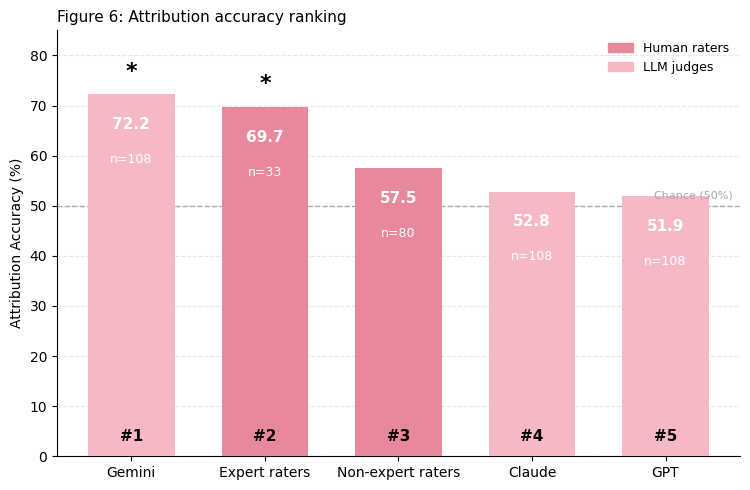

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import binomtest

# ── Reload if not in memory ───────────────────────────────────────────────────
try:
    dataset_B
except NameError:
    dataset_B = pd.read_csv("outputs/dataset_B_final.csv")

try:
    attr
except NameError:
    attr = pd.read_csv("llm_attribution_results.csv")
# Human raters from dataset_B
human_acc = (
    dataset_B.groupby("expertise")["attribution_correct"]
    .agg(n="count", correct="sum")
    .reset_index()
)
human_acc["accuracy"] = human_acc["correct"] / human_acc["n"] * 100
human_acc["key"] = human_acc["expertise"]

# LLM judges from attribution results
llm_acc = (
    attr.groupby("assessor_llm")["correct"]
    .agg(n="count", correct="sum")
    .reset_index()
)
llm_acc["accuracy"] = llm_acc["correct"] / llm_acc["n"] * 100
llm_acc["key"] = llm_acc["assessor_llm"]

# ── Combine ───────────────────────────────────────────────────────────────────
all_acc = pd.concat([
    human_acc[["key", "n", "correct", "accuracy"]],
    llm_acc[["key", "n", "correct", "accuracy"]],
], ignore_index=True)

# ── Significance via binomial test ────────────────────────────────────────────
def sig_marker(n_correct, n_total, chance=0.5):
    p = binomtest(int(n_correct), int(n_total), p=chance, alternative="two-sided").pvalue
    if p < 0.05:
        return "*"
    return ""

all_acc["sig"] = all_acc.apply(
    lambda r: sig_marker(r["correct"], r["n"]), axis=1
)

# ── Style ─────────────────────────────────────────────────────────────────────
COLOR_HUMAN = "#E8889B"
COLOR_LLM   = "#F6B8C4"
LABELS = {
    "expert":     "Expert raters",
    "non-expert": "Non-expert raters",
    "gemini":     "Gemini",
    "claude":     "Claude",
    "gpt":        "GPT",
}
COLORS = {
    "expert":     COLOR_HUMAN,
    "non-expert": COLOR_HUMAN,
    "gemini":     COLOR_LLM,
    "claude":     COLOR_LLM,
    "gpt":        COLOR_LLM,
}
MEDAL_COLORS = {
    1: "#F7E7A9",
    2: "#D9DEE8",
    3: "#E8C7A9",
    4: "#EDEDED",
    5: "#EDEDED",
}

# ── Rank ──────────────────────────────────────────────────────────────────────
all_acc = all_acc.sort_values("accuracy", ascending=False).reset_index(drop=True)
ranked  = all_acc["key"].tolist()
x       = np.arange(len(ranked))
bar_width = 0.65

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.6, 5.0), dpi=100)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

for i, row in all_acc.iterrows():
    key = row["key"]
    acc = row["accuracy"]
    col = COLORS.get(key, "#CCCCCC")

    ax.bar(x[i], acc, width=bar_width, color=col, zorder=3)

    ax.text(x[i], acc - 6, f"{acc:.1f}",
            ha="center", va="center",
            fontsize=11, color="white", fontweight="bold")

    ax.text(x[i], acc - 13, f"n={int(row['n'])}",
            ha="center", va="center",
            fontsize=9, color="white")

    ax.text(x[i], acc + 2.5, row["sig"],
            ha="center", va="bottom",
            fontsize=16, fontweight="bold")

    medal_color = MEDAL_COLORS.get(i + 1, "#EDEDED")
    ax.scatter(x[i], 4, s=900, color=medal_color, edgecolor="none", zorder=2)
    ax.text(x[i], 4, f"#{i+1}",
            ha="center", va="center",
            fontsize=11, fontweight="bold")

# ── Axes ──────────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels([LABELS.get(k, k.capitalize()) for k in ranked])
ax.set_ylabel("Attribution Accuracy (%)")
ax.set_ylim(0, 85)
ax.axhline(50, color="#aaaaaa", linestyle="--", linewidth=1, zorder=1)
ax.text(len(ranked) - 0.5, 51, "Chance (50%)",
        ha="right", va="bottom", fontsize=8, color="#aaaaaa")
ax.set_title(
    "Figure 6: Attribution accuracy ranking",
    loc="left", fontsize=11
)
ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_handles = [
    Patch(color=COLOR_HUMAN, label="Human raters"),
    Patch(color=COLOR_LLM,   label="LLM judges"),
]
ax.legend(handles=legend_handles, fontsize=9, frameon=False, loc="upper right")

plt.tight_layout()
plt.savefig("attribution_accuracy_medal_ranking.png", dpi=200, bbox_inches="tight")
plt.show()

/var/folders/rb/d7fy_s2n5q3f5g03krfs4skr0000gn/T/ipykernel_93289/2459199994.py:88: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_bounds = main_df.groupby("group", observed=True).apply(


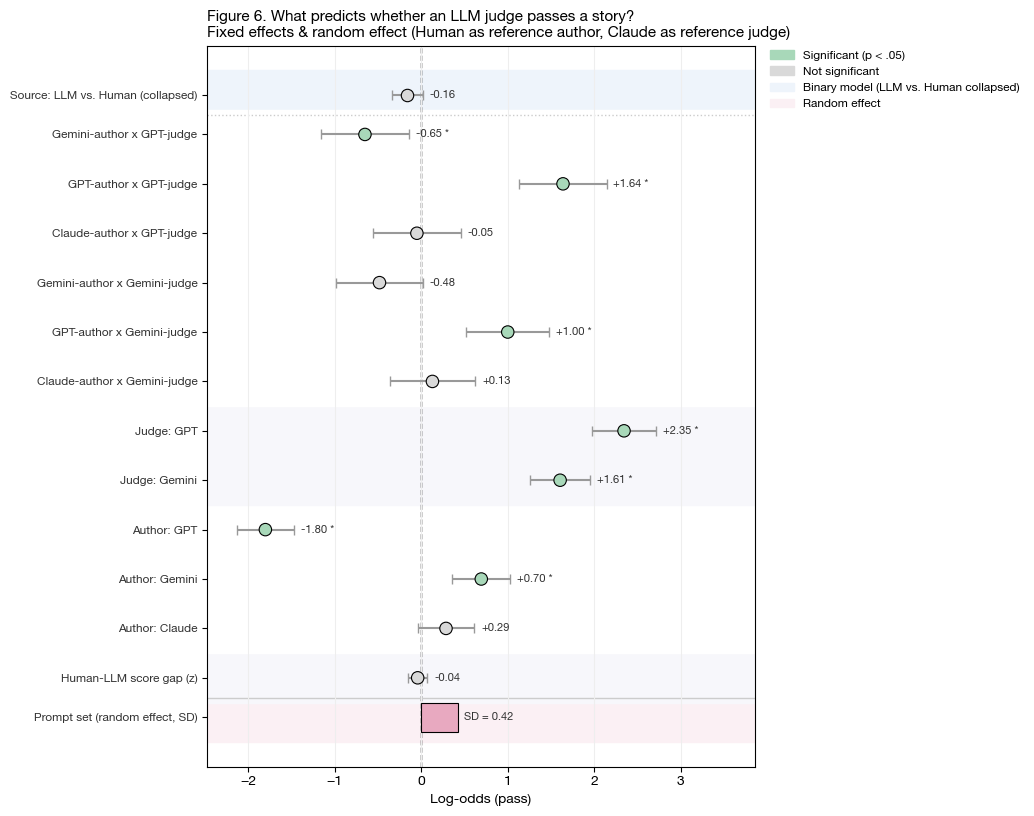

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Silka", "Helvetica Neue", "Arial", "DejaVu Sans"]

SIG_COLOR         = "#A8D8B9"
NOTSIG_COLOR      = "#D9D9D9"
RANDOM_COLOR      = "#E8A9C0"
RANDOM_BAND_COLOR = "#FBF0F4"
BINARY_BAND_COLOR = "#EEF4FB"
SECTION_BAND_COLORS = ["#F7F7FB", "#FFFFFF"]

def sig_color(p):
    return SIG_COLOR if p < 0.05 else NOTSIG_COLOR

z = 1.959964

# ── Binary model row ──────────────────────────────────────────────────────────
binary_rows = [
    ("source_binaryLLM", "Source (vs Human)", "Source: LLM vs. Human (collapsed)", -0.15902, 0.09165, 0.082727),
]

# ── Main model rows ───────────────────────────────────────────────────────────
main_rows = [
    ("author_factorClaude", "Author (vs Human)", "Author: Claude",  0.28786, 0.16812, 0.0868),
    ("author_factorGemini", "Author (vs Human)", "Author: Gemini",  0.69588, 0.17217, 5.31e-05),
    ("author_factorGPT",    "Author (vs Human)", "Author: GPT",    -1.80129, 0.16923, 2e-16),
    ("judge_factorgemini",  "Judge (vs Claude)", "Judge: Gemini",   1.60769, 0.17870, 2e-16),
    ("judge_factorgpt",     "Judge (vs Claude)", "Judge: GPT",      2.34689, 0.18761, 2e-16),
    ("author_factorClaude:judge_factorgemini", "Author x Judge interaction", "Claude-author x Gemini-judge",  0.13083, 0.25247, 0.6043),
    ("author_factorGPT:judge_factorgemini",    "Author x Judge interaction", "GPT-author x Gemini-judge",     1.00195, 0.24556, 4.50e-05),
    ("author_factorGemini:judge_factorgemini", "Author x Judge interaction", "Gemini-author x Gemini-judge", -0.48150, 0.25382, 0.0578),
    ("author_factorClaude:judge_factorgpt",    "Author x Judge interaction", "Claude-author x GPT-judge",    -0.04885, 0.25889, 0.8503),
    ("author_factorGPT:judge_factorgpt",       "Author x Judge interaction", "GPT-author x GPT-judge",        1.64099, 0.25710, 1.74e-10),
    ("author_factorGemini:judge_factorgpt",    "Author x Judge interaction", "Gemini-author x GPT-judge",    -0.64964, 0.26002, 0.0125),
    ("score_diff_z", "Story-score gap", "Human-LLM score gap (z)", -0.03976, 0.05617, 0.4790),
]

# ── Build dataframes ──────────────────────────────────────────────────────────
def build_df(rows, has_group=True):
    if has_group:
        df = pd.DataFrame(rows, columns=["term", "group", "Term", "estimate", "se", "p.value"])
    else:
        df = pd.DataFrame(rows, columns=["term", "group", "Term", "estimate", "se", "p.value"])
    df["conf.low"]  = df["estimate"] - z * df["se"]
    df["conf.high"] = df["estimate"] + z * df["se"]
    df["color"]     = df["p.value"].apply(sig_color)
    return df

binary_df = build_df(binary_rows)

GROUP_ORDER = ["Story-score gap", "Author (vs Human)", "Judge (vs Claude)", "Author x Judge interaction"]
main_df = build_df(main_rows)
main_df["group"] = pd.Categorical(main_df["group"], categories=GROUP_ORDER, ordered=True)
main_df = main_df.sort_values("group").reset_index(drop=True)

# ── Y-axis layout ─────────────────────────────────────────────────────────────
ROW_STEP = 0.75
GAP      = 0.6

random_label = "Prompt set (random effect, SD)"
random_sd    = 0.4214

n_main   = len(main_df)
n_binary = len(binary_df)

y_random = np.array([0.0])
y_main   = np.arange(n_main)   * ROW_STEP + y_random.max() + GAP
y_binary = np.arange(n_binary) * ROW_STEP + y_main.max()   + GAP

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10.5, 0.42 * (n_main + n_binary) + 2.8))

# background bands
ax.axhspan(y_random.min() - ROW_STEP * 0.5,
           y_random.max() + ROW_STEP * 0.5,
           color=RANDOM_BAND_COLOR, zorder=0)
ax.axhspan(y_binary.min() - ROW_STEP * 0.5,
           y_binary.max() + ROW_STEP * 0.5,
           color=BINARY_BAND_COLOR, zorder=0)

ax.grid(axis="x", color="#eeeeee", linewidth=0.8, zorder=0)

# section bands for main model groups
group_bounds = main_df.groupby("group", observed=True).apply(
    lambda g: (g.index.min(), g.index.max())
)
for i, (grp, (lo, hi)) in enumerate(group_bounds.items()):
    y_lo = y_main[lo] - ROW_STEP * 0.5
    y_hi = y_main[hi] + ROW_STEP * 0.5
    ax.axhspan(y_lo, y_hi, color=SECTION_BAND_COLORS[i % 2], zorder=0)

ax.axvline(0, color="black", linestyle="--", linewidth=1, zorder=1)
ax.axhline((y_random.max() + y_main.min()) / 2,
           color="#cccccc", linewidth=1, zorder=1)
ax.axhline((y_main.max() + y_binary.min()) / 2,
           color="#cccccc", linewidth=1, linestyle=":", zorder=1)

# ── Main model points ─────────────────────────────────────────────────────────
xerr_main = np.vstack([
    main_df["estimate"] - main_df["conf.low"],
    main_df["conf.high"] - main_df["estimate"],
])
ax.errorbar(main_df["estimate"], y_main, xerr=xerr_main, fmt="none",
            ecolor="#999999", elinewidth=1.5, capsize=3.5, zorder=2)
ax.scatter(main_df["estimate"], y_main, s=80,
           color=main_df["color"], edgecolor="black", linewidth=0.8, zorder=3)

for y, est, ci_hi, p in zip(y_main, main_df["estimate"],
                              main_df["conf.high"], main_df["p.value"]):
    sig_mark = " *" if p < 0.05 else ""
    ax.text(ci_hi + 0.08, y, f"{est:+.2f}{sig_mark}",
            va="center", fontsize=8, color="#333333")

# ── Binary model point ────────────────────────────────────────────────────────
xerr_binary = np.vstack([
    binary_df["estimate"] - binary_df["conf.low"],
    binary_df["conf.high"] - binary_df["estimate"],
])
ax.errorbar(binary_df["estimate"], y_binary, xerr=xerr_binary, fmt="none",
            ecolor="#999999", elinewidth=1.5, capsize=3.5, zorder=2)
ax.scatter(binary_df["estimate"], y_binary, s=80,
           color=binary_df["color"], edgecolor="black", linewidth=0.8, zorder=3)

for y, est, ci_hi, p in zip(y_binary, binary_df["estimate"],
                              binary_df["conf.high"], binary_df["p.value"]):
    sig_mark = " *" if p < 0.05 else ""
    ax.text(ci_hi + 0.08, y, f"{est:+.2f}{sig_mark}",
            va="center", fontsize=8, color="#333333")

# ── Random effect bar ─────────────────────────────────────────────────────────
ax.barh(y_random, [random_sd], height=ROW_STEP * 0.6,
        color=RANDOM_COLOR, edgecolor="black", linewidth=0.8, zorder=3)
ax.text(random_sd + 0.08, y_random[0], f"SD = {random_sd:.2f}",
        va="center", fontsize=8, color="#333333")

# ── Axes ──────────────────────────────────────────────────────────────────────
xlims = ax.get_xlim()
ax.set_xlim(xlims[0] - 0.1, xlims[1] + 0.9)

all_y      = np.concatenate([y_random, y_main, y_binary])
all_labels = ([random_label] +
              list(main_df["Term"]) +
              list(binary_df["Term"]))

ax.set_yticks(all_y)
ax.set_yticklabels(all_labels, fontsize=8.5, color="#333333")
ax.set_ylim(y_random.min() - ROW_STEP, y_binary.max() + ROW_STEP)
ax.set_xlabel("Log-odds (pass)", fontsize=10)
ax.set_title(
    "Figure 6. What predicts whether an LLM judge passes a story?\n"
    "Fixed effects & random effect (Human as reference author, Claude as reference judge)",
    fontsize=11, fontweight="bold", loc="left",
)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=SIG_COLOR,         label="Significant (p < .05)"),
    mpatches.Patch(color=NOTSIG_COLOR,       label="Not significant"),
    mpatches.Patch(color=BINARY_BAND_COLOR,  label="Binary model (LLM vs. Human collapsed)"),
    mpatches.Patch(color=RANDOM_BAND_COLOR,  label="Random effect"),
]
ax.legend(handles=legend_handles, loc="upper left",
          bbox_to_anchor=(1.02, 1), frameon=False,
          fontsize=8.5, borderaxespad=0)

plt.tight_layout()
plt.savefig("figure3_llm_raters_glmm.png", dpi=200, bbox_inches="tight")
plt.show()

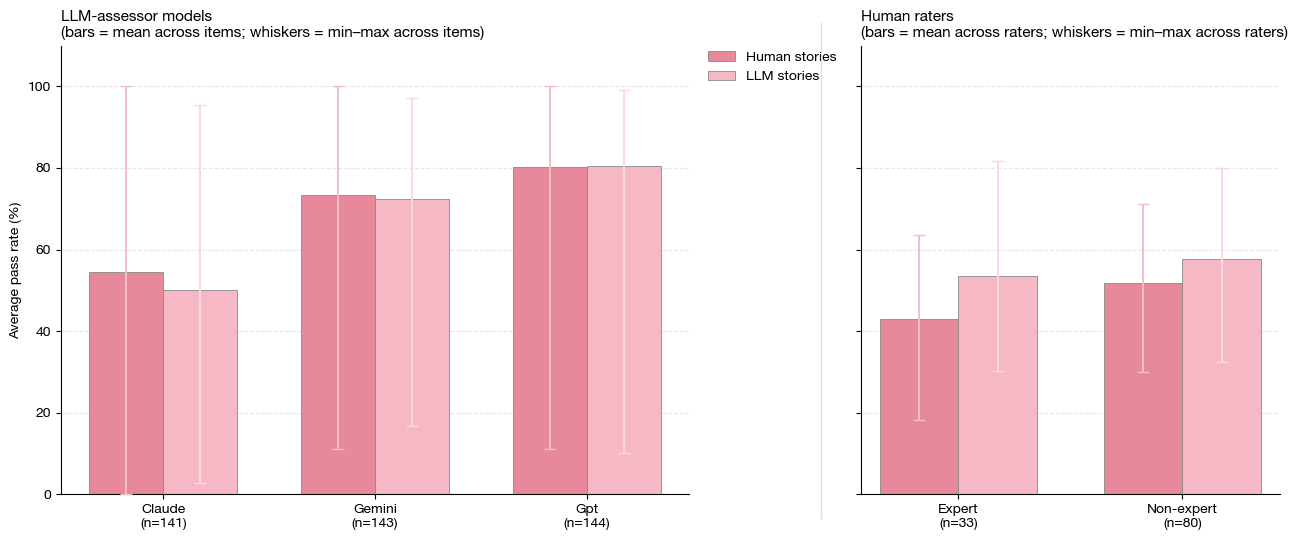

In [47]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Silka", "Helvetica Neue", "Arial", "DejaVu Sans"]

HUMAN_COLOR = "#E8889B"
LLM_COLOR   = "#F6B8C4"

def lighten(hex_color, amount=0.45):
    rgb   = np.array(mcolors.to_rgb(hex_color))
    white = np.array([1, 1, 1])
    return mcolors.to_hex(rgb + (white - rgb) * amount)

# ── LLM judge pass rates per judge × source ───────────────────────────────────
llm_item = (
    df_clean.groupby(["assessor", "source_binary", "item"])["pass"]
    .mean().reset_index()
)
llm_stats = (
    llm_item.groupby(["assessor", "source_binary"])["pass"]
    .agg(mean="mean", min="min", max="max")
    .reset_index()
)
llm_stats[["mean", "min", "max"]] *= 100

# ── Human rater pass rates per expertise × source ─────────────────────────────
model_data = pd.read_csv("model_data.csv")
human_item = (
    model_data.groupby(["expertise", "source", "question_id"])["pass"]
    .mean().reset_index()
)
human_stats = (
    human_item.groupby(["expertise", "source"])["pass"]
    .agg(mean="mean", min="min", max="max")
    .reset_index()
)
human_stats[["mean", "min", "max"]] *= 100

# ── N per group ───────────────────────────────────────────────────────────────
n_judges = df_clean.groupby("assessor")["item"].count() // df_clean["item"].nunique()
n_human  = model_data.groupby("expertise")["rater_id"].nunique()

# ── Layout ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5),
                          gridspec_kw={"width_ratios": [3, 2]},
                          sharey=True)
fig.patch.set_facecolor("white")

bar_w = 0.35

# ── LEFT PANEL: LLM judges ────────────────────────────────────────────────────
ax      = axes[0]
judges  = ["claude", "gemini", "gpt"]
x_pos   = np.arange(len(judges))
j_labels = [f"{j.capitalize()}\n(n={n_judges.get(j, '?')})" for j in judges]

for offset, source, color, label in [
    (-bar_w / 2, "Human", HUMAN_COLOR, "Human stories"),
    ( bar_w / 2, "LLM",   LLM_COLOR,   "LLM stories"),
]:
    means = []
    mins  = []
    maxs  = []
    for judge in judges:
        sub = llm_stats[
            (llm_stats["assessor"] == judge) &
            (llm_stats["source_binary"] == source)
        ]
        means.append(sub["mean"].values[0] if not sub.empty else np.nan)
        mins.append(sub["min"].values[0]   if not sub.empty else np.nan)
        maxs.append(sub["max"].values[0]   if not sub.empty else np.nan)

    means = np.array(means)
    mins  = np.array(mins)
    maxs  = np.array(maxs)
    yerr  = np.vstack([means - mins, maxs - means])
    whisker_color = lighten(color)

    ax.bar(x_pos + offset, means, width=bar_w, color=color,
           edgecolor="#888888", linewidth=0.6, label=label, zorder=2)
    ax.errorbar(x_pos + offset, means, yerr=yerr,
                fmt="none", ecolor=whisker_color,
                capsize=4, elinewidth=1.4, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels(j_labels)
ax.set_ylabel("Average pass rate (%)")
ax.set_ylim(0, 110)
ax.set_title(
    "LLM-assessor models\n(bars = mean across items; whiskers = min–max across items)",
    fontsize=11, fontweight="bold", loc="left"
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)

# ── RIGHT PANEL: Human raters ─────────────────────────────────────────────────
ax2     = axes[1]
groups  = ["expert", "non-expert"]
x_pos2  = np.arange(len(groups))
g_labels = [
    f"Expert\n(n={n_human.get('expert', '?')})",
    f"Non-expert\n(n={n_human.get('non-expert', '?')})",
]

for offset, source, color, label in [
    (-bar_w / 2, "Human", HUMAN_COLOR, "Human stories"),
    ( bar_w / 2, "LLM",   LLM_COLOR,   "LLM stories"),
]:
    means = []
    mins  = []
    maxs  = []
    for group in groups:
        sub = human_stats[
            (human_stats["expertise"] == group) &
            (human_stats["source"] == source)
        ]
        means.append(sub["mean"].values[0] if not sub.empty else np.nan)
        mins.append(sub["min"].values[0]   if not sub.empty else np.nan)
        maxs.append(sub["max"].values[0]   if not sub.empty else np.nan)

    means = np.array(means)
    mins  = np.array(mins)
    maxs  = np.array(maxs)
    yerr  = np.vstack([means - mins, maxs - means])
    whisker_color = lighten(color)

    ax2.bar(x_pos2 + offset, means, width=bar_w, color=color,
            edgecolor="#888888", linewidth=0.6, zorder=2)
    ax2.errorbar(x_pos2 + offset, means, yerr=yerr,
                 fmt="none", ecolor=whisker_color,
                 capsize=4, elinewidth=1.4, zorder=3)

ax2.set_xticks(x_pos2)
ax2.set_xticklabels(g_labels)
ax2.set_title(
    "Human raters\n(bars = mean across raters; whiskers = min–max across raters)",
    fontsize=11, fontweight="bold", loc="left"
)
ax2.spines[["top", "right"]].set_visible(False)
ax2.grid(axis="y", linestyle="--", alpha=0.3, zorder=0)

# ── Shared legend ─────────────────────────────────────────────────────────────
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1),
          frameon=False, borderaxespad=0)

# ── Divider ───────────────────────────────────────────────────────────────────
fig.add_artist(plt.Line2D(
    [0.635, 0.635], [0.05, 0.95],
    transform=fig.transFigure,
    color="#dddddd", linewidth=1
))

plt.tight_layout()
plt.savefig("fig_passrate_llm_human.png", dpi=200, bbox_inches="tight")
plt.show()

In [51]:
attr = pd.read_csv("llm_attribution_results.csv")

print(attr.groupby(["assessor_llm", "llm_source"])["correct"].agg(
    n="count", accuracy="mean"
).round(3) * 100)

                            n  accuracy
assessor_llm llm_source                
claude       claude      3600      41.7
             gemini      3600      52.8
             gpt         3600      63.9
gemini       claude      3600      63.9
             gemini      3600      52.8
             gpt         3600     100.0
gpt          claude      3600      38.9
             gemini      3600      55.6
             gpt         3600      61.1
